In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import glob, os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import datetime
from multiprocessing import Pool
import importlib

import functions.outlier_removal_single_float as outlier_removal
import functions.float_download_sprof_meta as fl_download
import functions.flag_sensor_info as fl_flags 
from tqdm import tqdm
import io
import functions.float_dataframe_utils as fl_df_utils


#### Load paths from user-generated file

In [2]:
# read in a user-created text file to point to local directories to avoid having to change this every time 
# we update code
lines=[]
with open('path_file.txt') as f:
    lines = f.readlines()
    
count = 0
for line in lines:
    count += 1
    index = line.find("=")
    #print(f'line {count}: {line}')
    #print(index)
    #print(line[0:index])
    line = line.rstrip()
    if line[0:index].find("argo")>=0:
        sprof_path=line[index+1:]
    # elif line[0:index].find("liar")>=0:
    #     liar_dir=line[index+1:]
    elif line[0:index].find("matlab")>=0:
        matlab_dir=line[index+1:]
        
# Set the path for the processed files
main_argo_dir = sprof_path + '../'
output_dir = main_argo_dir + 'processed/'
interpolated_directory = main_argo_dir + 'interpolated/'
# data_dir = 'data/'


# Check for needed directories, create if it does not exist
if not os.path.isdir(sprof_path):
    os.mkdir(sprof_path)
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)
if not os.path.isdir(interpolated_directory):
    os.mkdir(interpolated_directory)

# make a directory for saving float outlier figures if not already there
if not os.path.isdir('Figures/'):
    os.mkdir('Figures')

processed_fig_dir = output_dir + 'Processed_Figures/'
# make a directory for saving processed figures if not already there
if not os.path.isdir(processed_fig_dir):
    os.mkdir(processed_fig_dir)

local_outlier_dir = '../' + 'outlier_files/'
# make a directory for storing outlier files if not already there
if not os.path.isdir(local_outlier_dir):
    os.mkdir(local_outlier_dir)

group_outlier_dir = main_argo_dir + 'outlier_file_collection/'
# make a directory for storing outlier files if not already there
if not os.path.isdir(group_outlier_dir):
    os.mkdir(group_outlier_dir)

print('Float directory used: ' + sprof_path)

Float directory used: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/


In [124]:
#### Download Sprof and meta files - don't run every time
def argo_download(sprof_path):
    #get indices of BGC floats (DOXY, PH_IN_SITU_TOTAL, NITRATE)
    # First downloads the argo_synthetic-profile_index.txt file, then looks in that file for the wmo ids that correspond to BGC floats
    # probably should add a check for Fluor / Backscatter / Rad data at some point
    wmoids_doxy, gdac_index = fl_download.argo_gdac(save_to=sprof_path,sensors='DOXY',floats=None,
                                overwrite_index=True,
                                skip_download=True)
    wmoids_ph, gdac_index = fl_download.argo_gdac(save_to=sprof_path,sensors='PH_IN_SITU_TOTAL',floats=None,
                                skip_download=True)
    wmoids_nitrate, gdac_index = fl_download.argo_gdac(save_to=sprof_path,sensors='NITRATE',floats=None,
                                skip_download=True)
    #combine wmoids to one unique list
    wmoids = np.concatenate((wmoids_doxy,wmoids_ph,wmoids_nitrate))
    wmoids_all = np.unique(wmoids)
    wmoids_all = wmoids_all[~np.isnan(wmoids_all)].tolist()
    print('WMO IDs collected, ' + str(len(wmoids_all)) + ' floats to process ')

    #re-run argo_gdac with full list and download Sprof and meta files
    wmoids_bgc, gdac_index, downloaded_filenames = fl_download.argo_gdac(save_to=sprof_path,floats=wmoids_all,
                                skip_download=False, download_meta=True)
    
#### Function for plotting flag filtering if desired


# apply selected flags to data



In [125]:
### Download Core Argo data - only run if you specifically want non-bgc floats

def argo_core_download(prof_path):
    wmoids_core, gdac_index = fl_download.argo_gdac_CORE_floats(lat_range=[-90, 90],lon_range=None,start_date=None,end_date=None,sensors=None,floats=None,
                overwrite_index=False,overwrite_profiles=False,skip_download=True,
                download_individual_profs=False,download_meta=False,save_to=None,verbose=True)

    wmoids_all = wmoids_core[~np.isnan(wmoids_core)].tolist()
    wmoids_core_out, gdac_index_out, downloaded_filenames = fl_download.argo_gdac_CORE_floats(floats=wmoids_all,
                               skip_download=False, download_meta=False,save_to=prof_path, verbose=True, 
                               download_individual_profs=False)

### Check existing Sprof files, Query whether to download new files

In [126]:

# list number of argo files that already exist on the path
# get list of argo files
# can put in a flag here to select either sprof_path or SOCCOM_path (doesn't exist yet) to load SOCCOM data instead
argolist = []
for file in os.listdir(sprof_path):
    if file.endswith('Sprof.nc'):
        argolist.append(file)
print('Sprof_path is: ' + sprof_path)
print('Current number of sprof files on sprof_path: ' + str(len(argolist)))

query = "Do you want to download new data? (Y/N): "
response = input(query)

# Check the user's response and act accordingly
if response.upper() == "Y":
    print("Downloading new Sprof files.")
    argo_download(sprof_path)
elif response.upper() == "N":
    print("Skipping file download, continuing float processing")
    # Add your code here to perform actions when the user selects 'N'.
else:
    print("Invalid response. Please enter 'Y' for Yes or 'N' for No.")

print(' ')


Sprof_path is: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/
Current number of sprof files on sprof_path: 2429
Invalid response. Please enter 'Y' for Yes or 'N' for No.
 


### Apply flags, load meta data, save as temporary "Sprof_filtered" files

In [9]:
limited_test = 0 # 0- run all floats; 1- only run the number in "num_to_test"
if limited_test==1:
    num_to_test = 5
    print('Limited test run, Only processing the last ' + str(num_to_test) + ' floats')

rerun_flags = 1 #, 0 or 1 if set to 0, will only rerun files that do not have a filtered file created

flags_to_remove = [3,4]
# WOCE quality control flags:
# 0 - No QC
# 1 - Good
# 2 - Probably good
# 3 - Bad data, potentially correctable
# 4 - Bad data
# 5 - Value changed
# 6 - Not used
# 7 - Not used
# 8 - Estimated value
# 9 - Missing value (no data)

# get list of argo files 
argolist = []
for file in os.listdir(sprof_path):
    if file.endswith('Sprof.nc'):
        argolist.append(file)

if rerun_flags ==1:
    list_to_run = argolist
else:
    filtered_list = []
    for file in os.listdir(output_dir):
        if file.endswith('filtered.nc'):
            filtered_list.append(file)

    #check which files haven't been run yet
    list_to_run = []
    match = 0
    for file in argolist:
        for filtered in filtered_list:
            #check file against every filtered file name
            if file[0:7]==filtered[0:7]:
                match = 1 #if a match is found, toggle match to 1, break loop
                break

        if match==0: #only append if file is not found in filter list        
            list_to_run.append(file) # 
        else:
            match=0

if limited_test==1:
    temp_list = list_to_run.copy()
    list_to_run = []
    list_to_run = temp_list[0:num_to_test]
else:
    if rerun_flags ==1:
        print('Number of floats with no filtered file created: ' + str(len(list_to_run)))
    else:
        print('Processing all floats, n= ' + str(len(list_to_run)))


Number of floats with no filtered file created: 2429


In [4]:
# if you want to re-run specific floats, you can uncomment/edit these lines accordingly
list_to_run = ['1900943_Sprof.nc']
# list_to_run.append('5905505_Sprof.nc')
# list_to_run.append('5906636_Sprof.nc')
# list_to_run.append('5906624_Sprof.nc')
# list_to_run = list_to_run[0:1]

In [11]:
# flag filtering, parallel version

print('Setting flags ' + str(flags_to_remove) + ' to nan in newly created variables ("[VAR]_ADJUSTED_BGCArgoPlus"), adding sensor info and DOXY air/not air info')
print('Saving temporary "filtered" files in ' + output_dir)

from importlib import reload
reload(fl_flags)

num_processes = 6
verbose = False

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        filtered_args = [(sprof_path, file, flags_to_remove, output_dir, verbose) for n, file in enumerate(list_to_run)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_flags.sensor_flag_wrapper, filtered_args)
    


Setting flags [3, 4] to nan in newly created variables ("[VAR]_ADJUSTED_BGCArgoPlus"), adding sensor info and DOXY air/not air info
Saving temporary "filtered" files in /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/../processed/
Loading Sprof file: 5905194_Sprof.nc
Loading Sprof file: 6902972_Sprof.nc
Loading Sprof file: 1902621_Sprof.nc
Loading Sprof file: 4902598_Sprof.nc
Loading Sprof file: 1901378_Sprof.nc
Loading Sprof file: 5904691_Sprof.nc
Loading Sprof file: 6901650_Sprof.nc
Failed to add sensor info for 6901650_Sprof.nc check if meta.nc file exists
Loading Sprof file: 2900791_Sprof.nc
Loading Sprof file: 6990516_Sprof.nc
Loading Sprof file: 6901487_Sprof.nc
Loading Sprof file: 5906540_Sprof.nc
Loading Sprof file: 6900499_Sprof.nc
Loading Sprof file: 1901379_Sprof.nc
Loading Sprof file: 6903580_Sprof.nc
Loading Sprof file: 5905073_Sprof.nc
Loading Sprof file: 3901497_Sprof.nc
Loading Sprof file: 6901651_Sprof.nc
Failed 

In [ ]:
shallow_pressure = 500
np.max([shallow_pressure-250,0]).item()


250

In [ ]:
#### TESTING #####
file = '5905501_Sprof_filtered.nc'

argo_n = xr.open_dataset(output_dir + file)
argo_n
# vars = {'DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL', 'PRES', 'TEMP', 'PSAL', 'CHLA', 'BBP700'}
# for var in vars:
#     if var in argo_n.variables:
#         print(var)
#         print(argo_n[var + '_ADJUSTED_BGCArgoPlus_flag'].values.item())

### Run flag and mode filtered products only for comparison to Secondary QCed data

In [ ]:
rerun_flags = 1

flags_to_remove = [3,4]
# 0 - No QC
# 1 - Good
# 2 - Probably good
# 3 - Bad data, potentially correctable
# 4 - Bad data
# 5 - Value changed
# 6 - Not used
# 7 - Not used
# 8 - Estimated value
# 9 - Missing value (no data)

# get list of argo files 
argolist = []
for file in os.listdir(sprof_path):
    if file.endswith('Sprof.nc'):
        argolist.append(file)

if rerun_flags ==0:
    list_to_run = argolist
else:
    filtered_list = []
    for file in os.listdir(output_dir):
        if file.endswith('Sprof_flags_mode_only.nc'):
            filtered_list.append(file)

    #check which files haven't been run yet
    list_to_run = []
    match = 0
    for file in argolist:
        for filtered in filtered_list:
            #check file against every filtered file name
            if file[0:7]==filtered[0:7]:
                match = 1 #if a match is found, toggle match to 1, break loop
                break

        if match==0: #only append if file is not found in filter list        
            list_to_run.append(file) # 
        else:
            match=0

if rerun_flags ==1:
    print('Number of floats with no flag_mode file created: ' + str(len(list_to_run)))
else:
    print('Processing all floats, n= ' + str(len(list_to_run)))


Number of floats with no flag_mode file created: 818


In [ ]:
list_to_run = ['6902800_Sprof.nc']

In [ ]:
# flag, mode filtering ONLY, parallel version

print('Setting flags ' + str(flags_to_remove) + ' to nan in newly created variables')
print('Saving temporary "flag_mode" files in ' + output_dir)

from importlib import reload
reload(fl_flags)

num_processes = 6

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        filtered_args = [(sprof_path, file, flags_to_remove, output_dir, False) for n, file in enumerate(list_to_run)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_flags.flag_wrapper_only, filtered_args)
    


Setting flags [3, 4] to nan in newly created variables
Saving temporary "flag_mode" files in /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/../processed/


/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/Projects/2023_10 UHM_BGC_float_processing/code/functions/flag_sensor_info.py:1077: UserWarning: String dimension naming mismatch on variable None. 'STRING8' provided by encoding, but data has length of '7'. Using 'STRING7' instead of 'STRING8' to prevent possible naming clash.
To silence this warning either remove 'char_dim_name' from encoding or provide a fitting name.
  argo_n.to_netcdf(output_dir+filtered_file_name)
/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/Projects/2023_10 UHM_BGC_float_processing/code/functions/flag_sensor_info.py:1077: UserWarning: String dimension naming mismatch on variable None. 'STRING64' provided by encoding, but data has length of '14'. Using 'STRING14' instead of 'STRING64' to prevent possible naming clash.
To silence this warning either remove 'char_dim_name' from encoding or provide a fitting name.
  argo_n.to_netcdf(output_dir+filtered_file_name)
/Users/sethb

#### Testing cells:

In [ ]:
## TESTING - flag filtering # 
importlib.reload(fl_flags)    

# file = '4901806_Sprof.nc'
file = '5906220_Sprof_filtered.nc'

argo_n = xr.open_dataset(output_dir + file)

# argo_n = xr.open_dataset(sprof_path + file)
argo_n

In [ ]:
def apply_sensor_info(argo_n, file, sprof_path):
    meta_n = xr.open_dataset(sprof_path + file[0:7] + '_meta.nc')
    parameters_n = meta_n.PARAMETER.values
    air_cal_list = ['in air', 'in-air']
    confusing_air_cal_list = ['no in air', 'no in-air']

    # parameters_n = meta_n.PARAMETER.values
    # print(parameters_n)

    sensors = meta_n.SENSOR.values # using sensors instead of parameters, because parameters includes DOXY Temperature and length differs from sensor_models
    # print(sensors)

    sensor_models = meta_n.SENSOR_MODEL.values
    # print(sensor_models)

    for i in range(len(sensors)):
        # print(sensors[i])
        # print(sensor_models[i])
        argo_n[sensors[i].decode('utf-8').strip() + '_model'] = sensor_models[i].decode('utf-8').strip()
        argo_n[sensors[i].decode('utf-8').strip() + '_model'] = argo_n[sensors[i].decode('utf-8').strip() + '_model'].astype(dtype='object')

    # load calibration information from Sprof file 
    n_prof = argo_n.sizes['N_PROF']
    # gets order of sensors to extract calibration comments
    # some profiles might be missing sensor name (not sure why) so loop through looking
    o2_ind_all = np.full(n_prof, np.nan)
    # finds where o2 calibration comment is in each profile (at least for one float it changes from the first profile to the rest)
    for p in range(0, n_prof):
        cal_str = argo_n.STATION_PARAMETERS.values.astype(str)[p]
        # print(cal_str)
        for i, param in enumerate(cal_str):
            if 'DOXY' in param:
                o2_ind_all[p] = i
                break
    o2_cal_full = []
    for idx, o2_ind in enumerate(o2_ind_all):
        if ~np.isnan(o2_ind):
            o2_cal_full.append(argo_n.SCIENTIFIC_CALIB_COMMENT.values[idx,-1,np.int32(o2_ind)])

    data_comment_eq = pd.DataFrame({'o2_cal_full': o2_cal_full})
    # Drop duplicate comments
    unique_comments = data_comment_eq.drop_duplicates()
    # Create an empty list to store DataFrames
    data_frames = []
    # print(o2_cal_unique)
    # might have multiple unique comments, so save out each one:
    for i in unique_comments.index:
        o2_cal_i = unique_comments.o2_cal_full[i].decode("utf-8")

        # print(o2_cal_i)
        # save with wmo only for now
        new_data_cal_info = pd.DataFrame({ 'o2_cal_comment': [o2_cal_i]})
        # Append the new_data_cal_info DataFrame to the list
        data_frames.append(new_data_cal_info)

    cal_type = 'not_air'
    # assume if there are any air calibration comments for a float then I can label the entire float as "air_cal"
    for d in range(len(data_frames)):
        for air_str in air_cal_list:
            air_test = (data_frames[d].o2_cal_comment.str.contains(air_str))
            for conf_str in confusing_air_cal_list:
                confusing_test = (data_frames[d].o2_cal_comment.str.contains(conf_str))
            if air_test[0] and not confusing_test[0]:
                cal_type = 'air_cal'
                break
            
    argo_n['O2_cal_type'] = cal_type
    argo_n['O2_cal_type'] = argo_n['O2_cal_type'].astype(dtype='object')

    # add O2 sat
    return argo_n 

def apply_flags(argo_n, flags_to_remove, verbose):
    plot_flags = False

    #Load sprof file 
    # argo_n = xr.open_dataset(sprof_path + file)
    argo_n["WMO_ID"] = argo_n.PLATFORM_NUMBER.values.astype(int)[0]
    argo_n["WMO_ID"] = argo_n["WMO_ID"].astype(dtype='object')
    
    pres_data = argo_n['PRES_ADJUSTED'].values
    nprof_n = argo_n.sizes['N_PROF']

    if verbose:
        print('setting flagged data to nan')
    for key in argo_n.keys():
        if key.endswith('_QC'):
            if key.startswith('PROFILE_') or key=='JULD_QC':  #or key=='POSITION_QC'
                continue

            # if key=='POSITION_QC':
            #     argo_n[key[:-3] + '_BGCArgoPlus_flag'] = ''
            #     qc_val = argo_n[key].values.astype('float')
            #     if verbose:
            #         print('In flag removal loop ' + key[:-3])
            #     for flag in flags_to_remove:
            #     # argo_n[key[:-3]].values[qc_val==flag]=np.nan
            #     argo_n[key[:-3] + '_BGCArgoPlus'].values[qc_val==flag]=np.nan
            #     # print(argo_n[key[:-3] + '_BGCArgoPlus_flag'].values)

            #     argo_n[key + '_n_' + str(flag) + '_removed'] = np.sum(qc_val==flag) # save out the number of data points removed for a given flag 
            # argo_n[key[:-3] + '_BGCArgoPlus_flag'] = argo_n[key[:-3] + '_BGCArgoPlus_flag'].values.item() + 'F_'


            # need to check position QC separately from the rest and apply to lat/lon
            if np.logical_or(key=='POSITION_QC', key.__contains__('ADJUSTED')==True): # only apply flag filtering to ADJUSTED variables or Position
                
                # make a copy of variable, w/ "BGCArgoPlus" appended - Keeps original "Var_ADJUSTED" unchanged
                if key!='POSITION_QC':
                    argo_n[key[:-3] + '_BGCArgoPlus'] = argo_n[key[:-3]].copy()
                # create an empty string variable to contain information on what processing has been performed on different variables
                argo_n[key[:-3] + '_BGCArgoPlus_flag'] = ''
                # argo_n[key[:-3] + '_RO'] = argo_n[key[:-3]].copy()

                # print(key) if key.endswith('_QC') else None# 
                qc_val = argo_n[key].values.astype('float')
                if verbose:
                    print('In flag removal loop ' + key[:-3])
                # if key.startswith('PH'):
                #     break
                # sets data to nan (currently both raw and ADJUSTED, maybe can skip)
                for flag in flags_to_remove:
                    if key=='POSITION_QC':
                        argo_n['LATITUDE'].values[qc_val==flag]=np.nan
                        argo_n['LONGITUDE'].values[qc_val==flag]=np.nan
                    else:
                        argo_n[key[:-3] + '_BGCArgoPlus'].values[qc_val==flag]=np.nan
                    # print(argo_n[key[:-3] + '_BGCArgoPlus_flag'].values)

                    argo_n[key + '_n_' + str(flag) + '_removed'] = np.sum(qc_val==flag) # save out the number of data points removed for a given flag 
                argo_n[key[:-3] + '_BGCArgoPlus_flag'] = argo_n[key[:-3] + '_BGCArgoPlus_flag'].values.item() + 'F_'
            else:
                continue

            if plot_flags==1:
                qc_var_data = argo_n[key[:-3]].values
                plot_flag_filtering(argo_n, key, pres_data, qc_val, qc_var_data, nprof_n)
    
    #Finding and removing all non-delayed mode data
    # sometimes parameters are missing from profiles - 
    # need to loop through all profiles and check which parameters are present
    # assumes that mode applies to all levels of a profile
    parameter_array = argo_n.STATION_PARAMETERS.values.astype(str)
    all_parameters = []

    if verbose:
        print('checking profile data modes')
    for idx in range(len(parameter_array)): # loop through all profiles, idx is profile index 
        prof_parameters = parameter_array[idx] # get parameters present for each profile 
        # print(prof_parameters)

        # loop through each paramter in the profile 
        for var in prof_parameters:
            var_str = var.strip()
            if var_str=='':
                continue
            all_parameters.append(var_str)
            if var_str + '_profile_mode' not in argo_n: # if profile removed count has not been initialized, do so here 
                temp_var = {var_str + '_profile_mode':(['N_PROF'], np.zeros(len(argo_n['N_PROF'])))}
                argo_n = argo_n.assign(temp_var)
                argo_n[var_str + '_profile_mode'][:] = np.nan

            # if np.logical_or(len(var_str)==0, var_str=='PRES'): # only proceed if the variable exists and is not pressure
            #     continue
            # if np.logical_or(var_str=='TEMP', var_str=='PSAL'): # don't set TEMP or PSAL to nan for non-delayed mode data
            #     continue
            # if var_str + '_profile_removed_not_D' not in argo_n: # if profile removed count has not been initialized, do so here 
            #     argo_n[var_str + '_profile_removed_not_D'] = 0
            var_ind = [idx for idx, s in enumerate(prof_parameters) if s.strip()== var_str]
            # print(var_ind)

            # get parameter data mode values for that profile / variable
            var_data_mode = argo_n.PARAMETER_DATA_MODE[idx,var_ind].values
            # print(var_data_mode)
            # print(var_str)
            decoded_arr = np.array([elem.decode() if isinstance(elem, bytes) else np.nan for elem in var_data_mode.flatten()])
            if decoded_arr=='R':
                argo_n[var_str + '_profile_mode'][idx] = 0
            elif  decoded_arr=='A':
                argo_n[var_str + '_profile_mode'][idx] = 1
            elif  decoded_arr=='D':
                argo_n[var_str + '_profile_mode'][idx] = 2

            # # print(decoded_arr)
            # result = np.where(decoded_arr == 'D', False, True) # true whereever mode is not delayed
            # # print(result)
            # if result:
            #     argo_n[var_str +'_ADJUSTED_RO'][idx,:] = np.nan
            #     argo_n[var_str + '_profile_removed_not_D']+=1 # count the number of profiles removed b/c mode does not equal "D"
    if verbose:
        print('setting non-delayed mode profiles to nans')
    # set non delayed mode data to nan for now
    for var in np.unique(all_parameters):
        if var in {'NITRATE', 'DOXY', 'PH_IN_SITU_TOTAL'}:
            argo_n[var + '_ADJUSTED_BGCArgoPlus'][argo_n[var + '_profile_mode']!=2]=np.nan
            argo_n[var + '_ADJUSTED_BGCArgoPlus_flag'] = argo_n[var + '_ADJUSTED_BGCArgoPlus_flag'].values.item() + 'DMonly_'
    return argo_n
def surface_removal(argo_n, surface_cutoff, outlier_df):
    
    pres_var = 'PRES' # using the least QCd pressure in case Pressure isn't marked as good but there is valid BGC that that needs to be removed... 
    wmo = str(argo_n['WMO_ID'].values)

    n_prof = len(argo_n.N_PROF)
    plot_vars_all=[ 'TEMP_ADJUSTED_BGCArgoPlus',
                'PSAL_ADJUSTED_BGCArgoPlus',
                'NITRATE_ADJUSTED_BGCArgoPlus',
                'DOXY_ADJUSTED_BGCArgoPlus',
                'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus',]
    for p in range(n_prof):
        # find the presence of samples shallower than surface cutoff 
        surf_index = argo_n[pres_var][p,:]<surface_cutoff

        if any(surf_index): # if there are any true values
            # cycle through variables:
            var_removal_count = 0

            for var in plot_vars_all:
                if var in argo_n: # only do this for variables that are present
                    # first count number of non-nan instances of the variable in the surface
                    var_surf_index = np.logical_and(surf_index, ~np.isnan(argo_n[var][p,:]))

                    if any(var_surf_index): # if valid data needs to be removed
                        # print(var)
                        # add count to existing count for this variable:
                        if var + '_surface_samples_removed' not in argo_n: # if count has not been initialized, do so here 
                            argo_n[var + '_surface_samples_removed'] = np.sum(var_surf_index).values
                        else:
                            argo_n[var + '_surface_samples_removed'] = argo_n[var + '_surface_samples_removed'].values + np.sum(var_surf_index).values
                        outlier_df_n = pd.DataFrame({                 # creates a new "outlier_df" w wmo, variable name, profile, date, level, pressure, deletion reason 
                            "Float Number":[wmo]*np.sum(var_surf_index).values.item(),
                            "Variable":[var]*np.sum(var_surf_index).values.item(),
                            "N_PROF":[p]*np.sum(var_surf_index).values.item(),
                            "Date":[pd.to_datetime(argo_n['JULD'][p].values).strftime('%Y-%m-%d %H:%M:%S')]*np.sum(var_surf_index).values.item(),
                            "N_LEVELS":argo_n['N_LEVELS'][var_surf_index].values,
                            'Pressure (dbar)':argo_n['PRES'][p,var_surf_index].values,
                            'Deletion reason':['Surface Removal']*np.sum(var_surf_index).values.item()
                        })   
                        if len(outlier_df)==0:
                            outlier_df = outlier_df_n
                        else:
                            outlier_df = pd.concat([outlier_df, outlier_df_n])

                        # set surface obs to nan:
                        argo_n[var][p,var_surf_index] = np.nan
    for var in plot_vars_all:
        if var in argo_n: # only do this for variables that are present
            argo_n[var[:-12] + '_BGCArgoPlus_flag'] = argo_n[var[:-12] + '_BGCArgoPlus_flag'].values.item() + 'S_'

    # print('Finishing Surface Removal')
    return argo_n, outlier_df

def sigma0(salinity,temperature,lon,lat,pressure):
    SA = gsw.SA_from_SP(salinity,
                        pressure,
                        lon,
                        lat)

    CT = gsw.CT_from_t(SA,
                       temperature,
                       pressure)

    sigma = gsw.sigma0(SA,CT)
    
    return sigma

In [ ]:
## TESTING density inversions
file = '1901210_Sprof.nc'
import gsw

verbose = 'False'
argo_n = xr.open_dataset(sprof_path + file)

argo_n = apply_sensor_info(argo_n, file, sprof_path)

argo_n = apply_flags(argo_n, flags_to_remove, verbose)


outlier_df = pd.DataFrame({
            "Float Number": pd.Series(dtype="str"),
            "Variable": pd.Series(dtype="str"),
            "N_PROF": pd.Series(dtype="int"),
            "Date": pd.Series(dtype="str"),  # or "datetime64[ns]" if preferred
            "N_LEVELS": pd.Series(dtype="int"),
            "Pressure (dbar)": pd.Series(dtype="float"),
            "Deletion reason": pd.Series(dtype="str")
        })
        # Remove surface data (everything above Xm - seems to be contaminated with in-air data

argo_n, outlier_df = surface_removal(argo_n, 2, outlier_df)

# dens_thresh = -0.025 # acceptable density decrease

# # which temperature, salinity, and pressure are being checked? 
# temp_var = 'TEMP_ADJUSTED_BGCArgoPlus'
# sal_var = 'PSAL_ADJUSTED_BGCArgoPlus'
# pres_var = 'PRES_ADJUSTED_BGCArgoPlus'

# # argo_n = copy.deepcopy(argo_n)
# argo_n = argo_n.set_coords((pres_var, 'LONGITUDE', 'LATITUDE', 'JULD'))
# argo_n['Sigma_theta_gsw'] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_var].shape))
# argo_n.Sigma_theta_gsw[:] = np.nan

# n_prof = len(argo_n.N_PROF)
# wmo = str(argo_n['WMO_ID'].values)

# params_to_del = [sal_var]

# for par in params_to_del:
#     argo_n[par + '_flag'] = argo_n[par + '_flag'].values.item() + 'Inv_'

# # create copies of starting T and S to use for figures if a density inversion is found
# sal_orig = argo_n[sal_var].copy()
# temp_orig = argo_n[temp_var].copy()

# bad_data = 0
# removed_profile_record = []
# removed_pressure_record = []
# removed_var_record = []

# if verbose:
#     print('Searching each profile for density inversions')
# for p in range(n_prof):
#     # if verbose:
#         # print('Starting profile ' + str(p))
#     exit=0
#     while exit==0:
#         # count = 0
        
#         pres_p = argo_n[pres_var][p,:].sortby(pres_var).values.copy()
#         sal = argo_n[sal_var][p,:].sortby(pres_var).values
#         temp = argo_n[temp_var][p,:].sortby(pres_var).values

#         sigma_t_p = sigma0(sal,
#                                     temp,
#                                     argo_n.LONGITUDE[p].values,
#                                     argo_n.LATITUDE[p].values,
#                                     pres_p)
        
#         sigma_t_p_nonan = sigma_t_p[~np.isnan(sigma_t_p)]
#         pres_p_nonan = pres_p[~np.isnan(sigma_t_p)]
#         sal_p_nonan = sal[~np.isnan(sigma_t_p)]
#         # temp_p_nonan = temp[~np.isnan(sigma_t_p)]

#         # Check if there is a density profile
#         if len(sigma_t_p_nonan) < 2:
#             exit=1
#         else:
#             # Find most negative relative ([x+1]-[x]) and absolute (x - x[0]) difference
#             min_diff_rel = min(np.diff(sigma_t_p_nonan))
#             min_diff_tot = min(sigma_t_p_nonan-sigma_t_p_nonan[0])
#             abs_min = min(min_diff_rel,min_diff_tot) 
#             if abs_min < dens_thresh:  # if something trips the threshold, remove, otherwise go to the next profile 
#                 #print(f"bad density, profile no. {p}")

#                 bad_data += 1
#                 if min_diff_rel < min_diff_tot:
#                     outlier_index = np.argmin(np.diff(sigma_t_p_nonan))
#                 else:
#                     outlier_index = np.argmin(sigma_t_p_nonan-sigma_t_p_nonan[0])                
                    
#                 window_size = 3 
#                 df = pd.DataFrame({'Pressure':pres_p_nonan, 'Density':sigma_t_p_nonan})
#                 df['Density_rollmean'] = df['Density'].rolling(window=window_size, center=True).mean()
#                 if outlier_index+1==len(df):
#                     exit=1 
#                     continue
#                 diff1 = abs(df.loc[outlier_index, 'Density'] - df.loc[outlier_index, 'Density_rollmean'])
#                 diff2 = abs(df.loc[outlier_index+1, 'Density'] - df.loc[outlier_index+1, 'Density_rollmean'])

#                 if diff1 > diff2:   
#                     outlier_pres = [pres_p_nonan[outlier_index]]
#                     outlier_sal = [sal_p_nonan[outlier_index]]

#                 elif diff1 < diff2:
#                     outlier_pres = [pres_p_nonan[outlier_index+1]]
#                     outlier_sal = [sal_p_nonan[outlier_index+1]]

#                 else:
#                     outlier_pres = [ pres_p_nonan[outlier_index],pres_p_nonan[outlier_index+1] ]
#                     outlier_sal = [ sal_p_nonan[outlier_index],sal_p_nonan[outlier_index+1] ]

#                 for idx, i in enumerate(outlier_pres):
#                     for par in params_to_del:
#                         try:
#                             mask = argo_n[pres_var].isel(N_PROF=p).data == i
#                             # print(mask)
#                             argo_n[par].data[p,mask] = np.nan
#                             removed_profile_record.append(p)
#                             removed_pressure_record.append(i)
#                             removed_var_record.append(outlier_sal[idx])
#                             outlier_df_n = pd.DataFrame({                 # creates a new "outlier_df" w wmo, variable name, profile, date, level, pressure, deletion reason 
#                                             "Float Number":[wmo],
#                                             "Variable":[par],
#                                             "N_PROF":[p],
#                                             "Date":[pd.to_datetime(argo_n['JULD'][p].values).strftime('%Y-%m-%d %H:%M:%S')],
#                                             "N_LEVELS":[argo_n['N_LEVELS'][mask].values.item()],
#                                             'Pressure (dbar)':[i],
#                                             'Deletion reason':['Density Inversion']
#                                         })   
#                             if len(outlier_df)==0:
#                                 outlier_df = outlier_df_n
#                             else:
#                                 outlier_df = pd.concat([outlier_df, outlier_df_n])  
#                             # argo_n[par][p,:][argo_n[pres_var][p,:]==i] = np.nan
#                         except:
#                             pass # if parameter not present in argo_n
#             else:
#                 exit=1

# # save plots of bad profiles if they exist
# if bad_data>0:
#     def autoscale_plot(x, y, x_min, x_max, y_margin=0.1):
#         mask = (x >= x_min) & (x <= x_max)
#         y_data = y[mask]
#         if np.isnan(y_data).all():
#             raise ValueError("No valid data within specified x-range.")
#         y_min = np.nanmin(y_data)
#         y_max = np.nanmax(y_data)
#         y_range = y_max - y_min
#         y_lims = [y_min - y_range * y_margin, y_max + y_range * y_margin]
#         return y_lims
    
#     removed_profile_record = np.array(removed_profile_record)
#     removed_pressure_record = np.array(removed_pressure_record)
#     removed_var_record = np.array(removed_var_record)

#     unique_profiles = np.unique(removed_profile_record)
#     print(unique_profiles)
#     for p in unique_profiles:
#         if verbose:
#             print('Plotting and saving profile ' + str(p))
#         plot_filename = str(argo_n['WMO_ID'].values) + '_Density_Inversions_Removed_Profile_' + str(p)

#         selected_profile_index = removed_profile_record==p
#         profile_pressures_removed = removed_pressure_record[selected_profile_index]
#         profile_sal_removed = removed_var_record[selected_profile_index]

#         # min_pres = outlier_pres[0] - 10
#         # max_pres = outlier_pres[0] + 10

#         shallow_pressure = np.min(profile_pressures_removed)-20
#         deep_pressure = np.max(profile_pressures_removed)+20
#         fig = plt.figure()
#         ax = fig.add_subplot(1,3,1)
#         ax.plot(temp_orig[p,:], argo_n[pres_var][p,:],'x-', label='Orig')

#         # ax.set_ylim(max_pres,min_pres)
#         ax.set_autoscalex_on

#         ax1 = fig.add_subplot(1,3,2)
#         ax1.plot(sal_orig[p,:], argo_n[pres_var][p,:],'-x', label='Orig')

#         for idx, i in enumerate(profile_pressures_removed):
#             # ax1.plot(sal_orig[p,argo_n[pres_var][p,:]==i], i, 'ro')
#             ax1.plot(profile_sal_removed[idx], i, 'ro')




#         ax2 = fig.add_subplot(1,3,3)

#         orig_sigma_t_p = sigma0(sal_orig[p,:],
#                                     temp_orig[p,:],
#                                     argo_n.LONGITUDE[p].values,
#                                     argo_n.LATITUDE[p].values,
#                                     argo_n[pres_var][p,:])
#         new_sigma_t_p = sigma0(argo_n[sal_var][p,:],
#                                     argo_n[temp_var][p,:],
#                                     argo_n.LONGITUDE[p].values,
#                                     argo_n.LATITUDE[p].values,
#                                     argo_n[pres_var][p,:])

#         # 
#         ax2.plot(orig_sigma_t_p, argo_n[pres_var][p,:],'-')
#         ax2.plot(new_sigma_t_p, argo_n[pres_var][p,:],'m--')


#         # ax.set_ylim(deep_pressure, shallow_pressure)
#         # ax1.set_ylim(deep_pressure, shallow_pressure)
#         # ax2.set_ylim(deep_pressure, shallow_pressure)


#         # auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  temp_orig[p,:].values,   shallow_pressure, deep_pressure)
#         # if auto_x_lim[0]!=auto_x_lim[1]:
#         #     ax.set_xlim(auto_x_lim)

#         # auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  sal_orig[p,:].values,   shallow_pressure, deep_pressure)
#         # if auto_x_lim[0]!=auto_x_lim[1]:
#         #     ax1.set_xlim(auto_x_lim)

#         # auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  orig_sigma_t_p,   shallow_pressure, deep_pressure)
#         # if auto_x_lim[0]!=auto_x_lim[1]:
#         #     ax2.set_xlim(auto_x_lim)

#         ax.set_ylabel('Pressure')
#         ax.set_xlabel('T')
#         ax1.set_xlabel('S')
#         ax2.set_xlabel('PDENS')

#         ax.set_title(str(argo_n['WMO_ID'].values) + ' Profile: ' + str(p))
#         fig.tight_layout()

#         plt.savefig(f'{processed_fig_dir}{plot_filename}.png')
#         plt.close()
#         plt.clf()
# if verbose:
#     print('Finishing Density Inversion')

setting flagged data to nan
In flag removal loop POSITION
In flag removal loop PRES_ADJUSTED
In flag removal loop TEMP_ADJUSTED
In flag removal loop PSAL_ADJUSTED
In flag removal loop DOXY_ADJUSTED
checking profile data modes
setting non-delayed mode profiles to nans


In [ ]:
pres_p_nonan[outlier_index].item()>600

False

In [ ]:
def autoscale_plot(x, y, x_min, x_max, y_margin=0.1):
        mask = (x >= x_min) & (x <= x_max)
        y_data = y[mask]
        if np.isnan(y_data).all():
            raise ValueError("No valid data within specified x-range.")
        y_min = np.nanmin(y_data)
        y_max = np.nanmax(y_data)
        y_range = y_max - y_min
        y_lims = [y_min - y_range * y_margin, y_max + y_range * y_margin]
        return y_lims

In [ ]:
# argo_n = xr.open_dataset(sprof_path + file)

p=28

fig = plt.figure(figsize=(14,12))

pres_p = argo_n[pres_var][p,:].sortby(pres_var).values.copy()
sal = argo_n[sal_var][p,:].sortby(pres_var).values
temp = argo_n[temp_var][p,:].sortby(pres_var).values


# create copies of starting T and S to use for figures if a density inversion is found
sal_orig = argo_n[sal_var].copy()
temp_orig = argo_n[temp_var].copy()

sigma_t_p = sigma0(sal,
                            temp,
                            argo_n.LONGITUDE[p].values,
                            argo_n.LATITUDE[p].values,
                            pres_p)

sigma_t_p_nonan = sigma_t_p[~np.isnan(sigma_t_p)]
pres_p_nonan = pres_p[~np.isnan(sigma_t_p)]
sal_p_nonan = sal[~np.isnan(sigma_t_p)]
temp_p_nonan = temp[~np.isnan(sigma_t_p)]
# plot profiles of T, S, PDENS
ax = plt.subplot(2,3,1)
plt.plot(temp_p_nonan, pres_p_nonan,'x-')
ax.set_ylim([500,0])
ax.set_title(str(argo_n['WMO_ID'].values) + ' Profile: ' + str(p))

ax = plt.subplot(2,3,2)
plt.plot(sal_p_nonan, pres_p_nonan,'x-')
ax.set_ylim([500,0])

ax = plt.subplot(2,3,3)
plt.plot(sigma_t_p_nonan, pres_p_nonan,'x-')
ax.set_ylim([500,0])


min_diff_rel = min(np.diff(sigma_t_p_nonan))
min_diff_tot = min(sigma_t_p_nonan-sigma_t_p_nonan[0])
abs_min = min(min_diff_rel,min_diff_tot) 
print(min_diff_rel)
print(min_diff_tot)
print(abs_min)
if min_diff_rel < min_diff_tot:
    outlier_index = np.argmin(np.diff(sigma_t_p_nonan))
else:
    outlier_index = np.argmin(sigma_t_p_nonan-sigma_t_p_nonan[0])                
    
window_size = 3 
df = pd.DataFrame({'Pressure':pres_p_nonan, 'Density':sigma_t_p_nonan})
df['Density_rollmean'] = df['Density'].rolling(window=window_size, center=True).mean()
if outlier_index+1==len(df):
    exit=1
    print('no outliers remaining') 
    # continue
diff1 = abs(df.loc[outlier_index, 'Density'] - df.loc[outlier_index, 'Density_rollmean'])
diff2 = abs(df.loc[outlier_index+1, 'Density'] - df.loc[outlier_index+1, 'Density_rollmean'])

if diff1 > diff2:   
    outlier_pres = [pres_p_nonan[outlier_index]]
    outlier_sal = [sal_p_nonan[outlier_index]]

elif diff1 < diff2:
    outlier_pres = [pres_p_nonan[outlier_index+1]]
    outlier_sal = [sal_p_nonan[outlier_index+1]]

else:
    outlier_pres = [ pres_p_nonan[outlier_index],pres_p_nonan[outlier_index+1] ]
    outlier_sal = [ sal_p_nonan[outlier_index],sal_p_nonan[outlier_index+1] ]

sub_lim = [outlier_pres[0].item()+20, outlier_pres[0].item()-20]


auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  temp_orig[p,:].values,   sub_lim[1], sub_lim[0])

orig_sigma_t_p = sigma0(sal_orig[p,:],
                                    temp_orig[p,:],
                                    argo_n.LONGITUDE[p].values,
                                    argo_n.LATITUDE[p].values,
                                    argo_n[pres_var][p,:])

ax = plt.subplot(2,3,4)
plt.plot(temp_p_nonan, pres_p_nonan,'x-')
ax.set_ylim(sub_lim)
ax.set_title(str(argo_n['WMO_ID'].values) + ' Profile: ' + str(p))
ax.set_xlim(auto_x_lim)

auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  sal_orig[p,:].values,   sub_lim[1], sub_lim[0])
ax = plt.subplot(2,3,5)
plt.plot(sal_p_nonan, pres_p_nonan,'x-')
ax.set_ylim(sub_lim)
ax.set_xlim(auto_x_lim)

auto_x_lim = autoscale_plot(argo_n[pres_var][p,:].values,  orig_sigma_t_p,   sub_lim[1], sub_lim[0])
ax = plt.subplot(2,3,6)
plt.plot(sigma_t_p_nonan, pres_p_nonan,'x-')
ax.set_ylim(sub_lim)
ax.set_xlim(auto_x_lim)


KeyError: "No variable named 'PRES_ADJUSTED_BGCArgoPlus'. Variables on the dataset include [<this-array>]"

<Figure size 1400x1200 with 0 Axes>

In [ ]:
argo_n[pres_var][p,:].sortby(

KeyError: "No variable named 'PRES_ADJUSTED_BGCArgoPlus'. Variables on the dataset include [<this-array>]"

In [ ]:
min_diff_rel = min(np.diff(sigma_t_p_nonan))
min_diff_tot = min(sigma_t_p_nonan-sigma_t_p_nonan[0])
abs_min = min(min_diff_rel,min_diff_tot) 
print(min_diff_rel)
print(min_diff_tot)
print(abs_min)
if min_diff_rel < min_diff_tot:
    outlier_index = np.argmin(np.diff(sigma_t_p_nonan))
else:
    outlier_index = np.argmin(sigma_t_p_nonan-sigma_t_p_nonan[0])                
    
window_size = 3 
df = pd.DataFrame({'Pressure':pres_p_nonan, 'Density':sigma_t_p_nonan})
df['Density_rollmean'] = df['Density'].rolling(window=window_size, center=True).mean()
if outlier_index+1==len(df):
    exit=1
    print('no outliers remaining') 
    # continue
diff1 = abs(df.loc[outlier_index, 'Density'] - df.loc[outlier_index, 'Density_rollmean'])
diff2 = abs(df.loc[outlier_index+1, 'Density'] - df.loc[outlier_index+1, 'Density_rollmean'])

if diff1 > diff2:   
    outlier_pres = [pres_p_nonan[outlier_index]]
    outlier_sal = [sal_p_nonan[outlier_index]]

elif diff1 < diff2:
    outlier_pres = [pres_p_nonan[outlier_index+1]]
    outlier_sal = [sal_p_nonan[outlier_index+1]]

else:
    outlier_pres = [ pres_p_nonan[outlier_index],pres_p_nonan[outlier_index+1] ]
    outlier_sal = [ sal_p_nonan[outlier_index],sal_p_nonan[outlier_index+1] ]

-0.003168658734011842
-0.0009628045165754884
-0.003168658734011842


In [ ]:
removed_profile_record

array([ 28,  28, 108, 108, 108, 108])

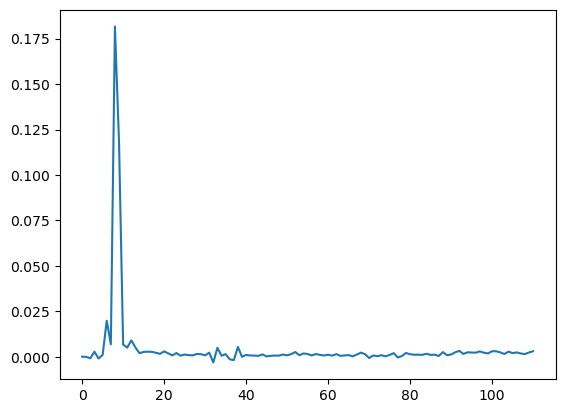

In [ ]:
plt.plot(np.diff(sigma_t_p_nonan))


### Outlier detection 

In [ ]:
## Run this once to avoid doing outlier detection when you don't need to bc of missing T/S/BGC

import functions.valid_bgc_check as valid_bgc_check
importlib.reload(valid_bgc_check)

filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)
print(len(filtered_list))

bgc_vars = ['NITRATE_ADJUSTED_BGCArgoPlus',
                'DOXY_ADJUSTED_BGCArgoPlus',
                'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus']

# flag filtering, parallel version

print('Checking filtered files for valid bgc, saving out outlier files with XXX as researcher if not')
print('Note, this only should need to be run once')


num_processes = 7
# verbose = True

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        filtered_args = [(output_dir, file, bgc_vars, local_outlier_dir) for n, file in enumerate(filtered_list)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(valid_bgc_check.check_for_valid_bgc, filtered_args)
    




2429
Checking filtered files for valid bgc, saving out outlier files with XXX as researcher if not
Note, this only should need to be run once


In [ ]:
# replaced by parallel code above, remove eventually
# # Check each file to see if there is valid data, creates an empty .csv file if not
# # get list of filtered files saved out
# filtered_list = []
# for file in os.listdir(output_dir):
#     if file.endswith('Sprof_filtered.nc'):
#         filtered_list.append(file)
# filtered_list = np.sort(filtered_list)

# plot_vars_all=[ 'TEMP_ADJUSTED_BGCArgoPlus',
#                 'PSAL_ADJUSTED_BGCArgoPlus',
#                 'NITRATE_ADJUSTED_BGCArgoPlus',
#                 'DOXY_ADJUSTED_BGCArgoPlus',
#                 'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus',]
# plot_vars = plot_vars_all.copy()
# researcher = 'XXX'
# for file in filtered_list:
#     argo_n = xr.open_dataset(output_dir + file)
#     # t_s_present = True
#     bgc_present=False
#     for idx, var in enumerate(plot_vars_all):
#         if var not in argo_n.keys():
#             continue
#         else: # Check if there are any valid bgc data. If not, don't bother doing outlier detection. 
#             if var in ['NITRATE_ADJUSTED_BGCArgoPlus',
#                     'DOXY_ADJUSTED_BGCArgoPlus',
#                     'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus',]:
#                 if np.sum(~np.isnan(argo_n[var]))>0:
#                     bgc_present = True
#             # also check that there is valid T/S data
#             # else:
#             #     if var in ['TEMP_ADJUSTED_RO',
#             #         'PSAL_ADJUSTED_RO']:
#             #         if np.sum(~np.isnan(argo_n[var]))==0:
#             #             t_s_present = False
#     if bgc_present==False:
#         # print('No valid bgc data in variables checked, skipping outlier removal')
#         empty_df = pd.DataFrame(columns = ["Status"], data=['No valid bgc'])
#         # break
#     # if t_s_present==False:
#     #     # print('Missing either valid T or valid S, skipping outlier removal')
#     #     empty_df = pd.DataFrame(columns = ["Status"], data=['Missing valid T or S'])
#     #     # break## Run this once to avoid doing outlier detection when you don't need to bc of missing T/S/BGC

#     # if np.logical_or(bgc_present==False, t_s_present==False):
#     if bgc_present==False:
#         savename = '../outlier_files/outliers_' + file[0:-3] + '_' + researcher
#         current_time = datetime.datetime.now()
#         current_time_str = str(current_time.year) + '_' + str(current_time.month) + '_' + str(current_time.day) + '_' + str(current_time.hour)
#         empty_df.to_csv(savename + '_' + current_time_str + '.csv', mode='w', index=False, header=True)

In [ ]:
#### Optional ### find pH floats only. Only need to run this if you are focusing on pH for outlier detection, or load the list below
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        argolist.append(file)

print(len(argolist))
ph_var = 'PH_IN_SITU_TOTAL_ADJUSTED_RO'
# find floats that have valid pH
float_pH_list = []
for n, file in enumerate(argolist):
    argo_n = xr.open_dataset(output_dir + file)
    if ph_var in argo_n.keys():
        if np.sum(~np.isnan(argo_n[ph_var]))>0:
            float_pH_list.append(file)
float_pH_list = np.sort(float_pH_list)   
print(len(float_pH_list))
np.save('plotting_scripts/pH_file_list.npy', float_pH_list )


2229


KeyboardInterrupt: 

In [3]:
#### Optional (alternative to cell above) ### load of list instead of cell above - only needed if you want to focus on pH floats
float_pH_list = np.load('plotting_scripts/pH_file_list.npy')
print(len(float_pH_list))

438


In [4]:
## Outlier Removal Cell - will load each float - if outliers are removed, will save identified points in a .csv file
# If no outliers are identified, creates and saves an empty .csv file to indicate that the float has been checked for outliers 
# option tree:
# All false - look at all floats
# no outlier file - look at all files with no outlier file generated
# only_one_outlier_researcher - outlier files with only one evaluator that does not match the input initials
    # if ph_floats_in_particular = True, then will add additional constraint of floats that have pH that you have not evaluated

import io 
from importlib import reload

importlib.reload(outlier_removal)    

no_outlier_file = False # if True, returns a list of floats with no outlier files, can do this either in your own directory or in the group directory
remove_researcher_files = True # excludes floats that you have already looked at
pH_floats_in_particular = True # if true, gives a list of pH floats the researcher has not looked at yet. Must run the preceding block of code first
only_one_outlier_researcher = False  # if true, only gives a list of floats that only one person has looked at so far
only_seth = False
# do_detec = input('Do you want to perform the outlier detection ? (y/n)')

# if do_detec.lower()=='n':
#     input('Do you want to read outliers from a file? (y/n)')
#     print('NOT IMPLEMENTED YET')
# elif do_detec.lower() == 'y' :
researcher = input('ENTER initials to be appended to outlier detection file, ex: SMB. Helps keep track of which floats have been assessed by multiple people.')
    
# get list of filtered files saved out
filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)
# run outlier detection code or read in .csv file of bad data
# loop through all "filtered" files in argolist

outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

outlier_list = np.sort(outlier_list)
outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
# remove all "bottomoxygen" files from the outlier_df:
# outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all "automaticoutliers" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')

if only_one_outlier_researcher:
    outlier_df_wmo_grouped = outlier_df.groupby('wmo')
    # print('here')
    filtered_list = []
    # different than some of the other options, here we are putting together a list of what still needs to be done, not what has already been done
    for outlier_n in outlier_df_wmo_grouped: # loop through every wmo that has been evaluated
        if np.sum(outlier_n[1]['person']=='XXX')>0: #if marked as bad, skips adding this to the list 
            continue
        # make sure you aren't double counting someone who has used their initials as capital and lowercase on the same float
        people = []
        for person in outlier_n[1]['person'].values:
            people.append(person.lower())
        if len(np.unique(people))<2: # if only one person has evaluated the file, 
            if only_seth: # if this has only been reviewed by Seth, then add it to the list
                trimmed = outlier_n[1].where(np.logical_or(outlier_n[1]['person']=='smb', 
                                 outlier_n[1]['person']=='SMB')).dropna(how='all')
            elif remove_researcher_files:    # or if that person is not the researcher:
                trimmed = outlier_n[1].where(outlier_n[1]['person']!=researcher.lower()).dropna(how='all')
                trimmed = trimmed.where(outlier_n[1]['person']!=researcher.upper()).dropna(how='all')
            else:
                trimmed = outlier_n[1]

            # then add the wmo to the filtered list
            if len(trimmed)>0:
                if pH_floats_in_particular: # check if this file is in the float pH list and only add if it is
                    if str(int(outlier_n[0]))+'_Sprof_filtered.nc' in float_pH_list:
                        filtered_list.append(str(int(outlier_n[0]))+'_Sprof_filtered.nc')
                else:
                    filtered_list.append(str(int(outlier_n[0]))+'_Sprof_filtered.nc')
    # print(len(filtered_list))
    # if pH_floats_in_particular:
    #     un_evaluated_list = set(float_pH_list) - set(evaluated_list)
    # else:
    #     un_evaluated_list = set(filtered_list) - set(evaluated_list)
    # filtered_list = list(un_evaluated_list)
    filtered_list = np.sort(filtered_list)
    
elif remove_researcher_files:
    mask1 = outlier_df['person']==researcher.lower()
    mask2 = outlier_df['person']==researcher.upper()
    mask3 =  outlier_df['person']=='XXX'
    outlier_single_person = outlier_df.where(mask1 | mask2 | mask3).dropna(how='all') # selecting all of the outliers that have been done by the researcher entered at the prompt
    outliers_unique_wmo_list = np.unique(outlier_single_person['wmo'])
   
    evaluated_list = []
    for wmo in outliers_unique_wmo_list:
        evaluated_list.append(str(int(wmo))+'_Sprof_filtered.nc')
    if pH_floats_in_particular:
        un_evaluated_list = set(float_pH_list) - set(evaluated_list)
    else:
        un_evaluated_list = set(filtered_list) - set(evaluated_list)
    filtered_list = list(un_evaluated_list)
    filtered_list = np.sort(filtered_list)

elif no_outlier_file:
    
    outliers_unique_wmo_list = np.unique(outlier_df['wmo'])

    evaluated_list = []
    for wmo in outliers_unique_wmo_list:
        evaluated_list.append(str(int(wmo))+'_Sprof_filtered.nc')

    un_evaluated_list = set(filtered_list) - set(evaluated_list)
    filtered_list = list(un_evaluated_list)
    filtered_list = np.sort(filtered_list)
    
print(len(filtered_list))

#  calling outlier_removal on a per float basis. 

idx = input('What index do you want to start at (0 to ' + str(len(filtered_list)-1) + ')? You can also enter a float WMO number to start at a specific float.')

if int(idx) > 1000000: # if gave a float number
    idx = [int(i) for i, x in enumerate(filtered_list) if idx in x][0]

for float_index in range(int(idx), len(filtered_list)):
    print('Index: ' + str(float_index) + ', WMO: ' + filtered_list[float_index])
    success = outlier_removal.pre_load_data(output_dir, file=filtered_list[float_index], researcher=researcher, port_num=8057, verbose=False)   
    next_query = input('When ready to go to the next float, hit any key (then press enter), or type "exit" to leave this loop')
    
    # Always saves an outlier file now, even if exiting.
    # Check if identified outliers, and if not save empty csv file
    savename = '../outlier_files/outliers_' + filtered_list[float_index][0:-3] + '_' + researcher.lower()

    outlier_csv_list = os.listdir('../outlier_files/')
    wmo_str = filtered_list[float_index][0:-3].split('_')[0]
    
    if any(wmo_str in s for s in outlier_csv_list) == False:
        current_time = datetime.datetime.now()
        current_time_str = str(current_time.year) + '_' + str(current_time.month) + '_' + str(current_time.day) + '_' + str(current_time.hour)
            
        if success==False:
            empty_df = pd.DataFrame(columns = ["Status"], data=['Failed to load'])
        else:
            
            empty_df = pd.DataFrame(columns = ["Float Number","Variable","N_PROF","Date","N_LEVELS",'Pressure (dbar)','Deletion reason'])
        empty_df.to_csv(savename + '_' + current_time_str + '.csv', mode='w', index=False, header=True)

    if next_query.lower()=='exit': # exits script
        break

45
Index: 0, WMO: 5905377_Sprof_filtered.nc
5905377_Sprof_filtered.nc
['TEMP_ADJUSTED_BGCArgoPlus', 'PSAL_ADJUSTED_BGCArgoPlus', 'NITRATE_ADJUSTED_BGCArgoPlus', 'DOXY_ADJUSTED_BGCArgoPlus', 'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus']
Dash app running on http://127.0.0.1:8057/
Index: 1, WMO: 5905379_Sprof_filtered.nc
5905379_Sprof_filtered.nc
['TEMP_ADJUSTED_BGCArgoPlus', 'PSAL_ADJUSTED_BGCArgoPlus', 'NITRATE_ADJUSTED_BGCArgoPlus', 'DOXY_ADJUSTED_BGCArgoPlus', 'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus']
Dash app running on http://127.0.0.1:8057/
Index: 2, WMO: 5905634_Sprof_filtered.nc
5905634_Sprof_filtered.nc
['TEMP_ADJUSTED_BGCArgoPlus', 'PSAL_ADJUSTED_BGCArgoPlus', 'NITRATE_ADJUSTED_BGCArgoPlus', 'DOXY_ADJUSTED_BGCArgoPlus', 'PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus']
Dash app running on http://127.0.0.1:8057/
Index: 3, WMO: 5905636_Sprof_filtered.nc
5905636_Sprof_filtered.nc
['TEMP_ADJUSTED_BGCArgoPlus', 'PSAL_ADJUSTED_BGCArgoPlus', 'NITRATE_ADJUSTED_BGCArgoPlus', 'DOXY_ADJUSTED_BGCArgoPlus

#### Testing cells:

In [ ]:
argo_n = xr.open_dataset(output_dir + '1900650_Sprof_filtered.nc')
plot_vars_all=[ 'TEMP_ADJUSTED_RO',
                'PSAL_ADJUSTED_RO',
                'NITRATE_ADJUSTED_RO',
                'DOXY_ADJUSTED_RO',
                'PH_IN_SITU_TOTAL_ADJUSTED_RO',]

In [ ]:
## TESTING ##
output_dir
file = '2902087_Sprof_filtered.nc'
verbose=True
plot_vars_all=[ 'TEMP_ADJUSTED_RO',
                'PSAL_ADJUSTED_RO',
                'NITRATE_ADJUSTED_RO',
                'DOXY_ADJUSTED_RO',
                'PH_IN_SITU_TOTAL_ADJUSTED_RO',]

In [ ]:
## TESTING - 
argo_n = xr.open_dataset(output_dir + file)
plot_vars = plot_vars_all.copy()
bgc_present=False
for idx, var in enumerate(plot_vars_all):
        if var not in argo_n.keys():
            plot_vars.remove(var)
        else: # Check if there are any valid bgc data. If not, don't bother doing outlier detection. 
            if var in ['NITRATE_ADJUSTED_RO',
                    'DOXY_ADJUSTED_RO',
                    'PH_IN_SITU_TOTAL_ADJUSTED_RO',]:
                if np.sum(~np.isnan(argo_n[var]))>0:
                    bgc_present = True
            # also check that there is valid T/S data
            # else: # for now, stop checking if there is "_RO" temp or sal data, show anyway
            #     if var in ['TEMP_ADJUSTED_RO',
            #         'PSAL_ADJUSTED_RO']:
            #         if np.sum(~np.isnan(argo_n[var]))==0:
            #             t_s_present = False

argo_vars = argo_n[plot_vars+['PRES_ADJUSTED_RO','CYCLE_NUMBER','JULD','LATITUDE','LONGITUDE', 'PRES_ADJUSTED', 'TEMP_ADJUSTED', 'PSAL_ADJUSTED','TEMP', 'PSAL', 'PRES']] # adding TEMP_ADJUSTED and PSAL_ADJUSTED so we can use them if data is missing
df = argo_vars.to_dataframe()
dfs = df


In [ ]:
## TESTING - Checking for valid data
argo_n = xr.open_dataset(output_dir + file)
for var in plot_vars_all:

    var_parts = var.split('_')
    # print(var_parts)

    if var in argo_n.keys():
        var_name = var_parts[0]
        valid_data = argo_n[var_name]
        print(var_name)
        print(np.sum(~np.isnan(valid_data.values)))

        var_name = var_parts[0] + '_ADJUSTED'
        valid_data = argo_n[var_name]
        print(var_name)
        print(np.sum(~np.isnan(valid_data.values)))

        var_name = var_parts[0] + '_ADJUSTED_RO'
        valid_data = argo_n[var_name]
        print(var_name)
        print(np.sum(~np.isnan(valid_data.values)))

        print(argo_n[var_parts[0] + '_ADJUSTED_QC_n_3_removed'].values)
        print(argo_n[var_parts[0] + '_ADJUSTED_QC_n_4_removed'].values)
        # print(argo_n[var_parts[0] + '_profile_removed_not_D'].values)



In [ ]:
## TESTING load_dataset ##
# load_dataset(output_dir, file, plot_vars_all, verbose):
import functions.find_density_inversions as func_inv
import functions.find_wiggles_peak_version as wiggle

importlib.reload(outlier_removal)    
importlib.reload(func_inv)    

if verbose==True:
        print('initial dataset load')
argo_n = xr.open_dataset(output_dir + file)

# Identify density inversions
if verbose==True:
    print('Dataset loaded, starting density inversions')
levels_inv, prof_inv, points_dens_inversion = func_inv.density_inversion(argo_n, verbose)
if verbose==True:
    print('Density inversion function finished')
    
# Identify oxygen increase in last profile point
#levels_bo, prof_bo, points_bad_oxy = func_badoxybottom.badoxy_bottom(argo_n)

# check both nitrate and oxygen for wiggly profiles
vars_to_check_for_wiggles = ['DOXY_ADJUSTED_RO', 'NITRATE_ADJUSTED_RO']
for idx, var in enumerate(vars_to_check_for_wiggles):
    if var in argo_n.keys():
        # print(var)
        problem_profiles_var = wiggle.peak_detect_wiggles(output_dir, argo_n, var=var)
        # print(problem_profiles_var)
        if idx==0:
            problem_profiles = problem_profiles_var
        elif len(problem_profiles_var)>0:
            problem_profiles = np.concatenate((problem_profiles, problem_profiles_var))
        # print(problem_profiles)

problem_profiles = np.unique(problem_profiles)
    
# problem_profiles = wiggle.peak_detect_wiggles(output_dir, file = file ,var="DOXY_ADJUSTED")

plot_vars = plot_vars_all.copy()
bgc_present=False
for idx, var in enumerate(plot_vars_all):
    
    if var not in argo_n.keys():
        plot_vars.remove(var)
    else: # Check if there are any valid bgc data. If not, don't bother doing outlier detection. 
        if var in ['NITRATE_ADJUSTED_RO',
                'DOXY_ADJUSTED_RO',
                'PH_IN_SITU_TOTAL_ADJUSTED_RO',]:
            if np.sum(~np.isnan(argo_n[var]))>0:
                bgc_present = True

if bgc_present==False:
    print('No valid bgc data in variables checked, skipping outlier removal')
    # global stop_script
    # stop_script = True
    # raise GracefulExit  # Raises a custom exception
    # return None, None, None, None, [None, None, None]
argo_vars = argo_n[plot_vars+['PRES_ADJUSTED_RO','CYCLE_NUMBER','JULD','LATITUDE','LONGITUDE', 'TEMP_ADJUSTED', 'PSAL_ADJUSTED']] # adding TEMP_ADJUSTED and PSAL_ADJUSTED so we can use them if data is missing

df = argo_vars.to_dataframe()
df = df.reset_index()

# Set number of profiles to plot per figure as well as group profiles into ranges
num_profiles_per_fig = 5
finishing_prof = 0
label_lists = []
for i, data in df.groupby("N_PROF"):
    if i%num_profiles_per_fig == 0:
        starting_prof = i
    finishing_prof = starting_prof + 4
    label = str(starting_prof) + "-" + str(finishing_prof)
    label_list = [label] * len(data)
    label_lists = label_lists + label_list
df["Profile Range"] = label_lists

# # assign integer number tied to profile range i.e. 1:'0-4', 2:'5-9'
marker_dict = {}
for i, profiles in enumerate(df['Profile Range'].unique()):
    profiles_expanded = range(int(profiles.split('-')[0]), int(profiles.split('-')[1]))
    color = '#000000'
    for problem_profile in problem_profiles:
        if problem_profile in profiles_expanded:
            color = '#eb3434'
    marker_dict[i] = {
        'label':profiles,
        'style':{'color': color}
    }
    
# try setting pressure range for each time series slider range to keep similar data together
pressure_ranges_for_ts =[20, 40, 70, 100, 150, 200, 250, 350, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]

pressure_labels_list = []

pressure_labels_list.append( '%i-%i'%(0, pressure_ranges_for_ts[0]) )
for idx, lev in enumerate(pressure_ranges_for_ts[0:-1]):
    pressure_labels_list.append( '%i-%i'%(pressure_ranges_for_ts[idx]+1, pressure_ranges_for_ts[idx+1]) )
pressure_labels_list

idx = np.digitize(df.PRES_ADJUSTED_RO, pressure_ranges_for_ts[0:-1])
idx, len(pressure_labels_list)

df['Pressure Range'] = [pressure_labels_list[i] for i in idx]


# # assign integer number tied to level range i.e. 1:'0-4', 2:'5-9'
press_ranges_sorted = df['Pressure Range'].unique()
# Sorting function based on the lower bound of the range
def sort_key(range_str):
    return int(range_str.split('-')[0])

sorted_arr = sorted(press_ranges_sorted, key=sort_key)

pressures_dict = {i: levels for i, levels in enumerate(sorted_arr)}

In [ ]:
# Try to remove outlier files where T/S was originally removed due to not being delayed mode

filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)

outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

# print(len(outlier_list))

import io 

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)

outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
for file in tqdm(filtered_list):
    # file = '2901558_Sprof_filtered.nc'
    argo_n = xr.open_dataset(output_dir + file)

    # check if any outlier files exist for this one:
    try:
        argo_n["WMO_ID"] = argo_n.PLATFORM_NUMBER.values.astype(int)[0]
    except:
        print('Error in file ' + file)
        continue
    
    outlier_file_matches = outlier_df.where(outlier_df['wmo']==int(argo_n["WMO_ID"].values)).dropna(how='all')
    if len(outlier_file_matches)==0:
        # print('here1')
        continue
    # is an 'XXX' file present, indicating that this float should be skipped?
    XXX_files = outlier_file_matches.where(outlier_file_matches['person']=='XXX').dropna(how='all')
    if len(XXX_files)>0:
        # print('here2')

        continue # no need to keep going if XXX file is present 

    non_XXX_files = outlier_file_matches.where(outlier_file_matches['person']!='XXX').dropna(how='all')

    files_empty = 1
    for i in range(len(non_XXX_files)):
        csv_file = open(group_outlier_dir+outlier_list[non_XXX_files.index[i]])
        df_out = pd.read_csv(csv_file)
        if len(df_out)>0:
                files_empty=0

    # if files_empty is still set to 0, then need to check if this is empty because T/S would have prevented its being run before:
    if files_empty==0:
        # print('here2.5')
        continue
    
    argo_n["WMO_ID"] = argo_n["WMO_ID"].astype(dtype='object')

    pres_data = argo_n['PRES_ADJUSTED'].values
    nprof_n = argo_n.sizes['N_PROF']


    #Finding and removing all non-delayed mode data
    # sometimes parameters are missing from profiles - 
    # need to loop through all profiles and check which parameters are present
    # assumes that mode applies to all levels of a profile
    parameter_array = argo_n.STATION_PARAMETERS.values.astype(str)

    for idx in range(len(parameter_array)): # loop through all profiles, idx is profile index 
        prof_parameters = parameter_array[idx] # get parameters present for each profile 
        # print(prof_parameters)
        # print('here3')

        # loop through each paramter in the profile 
        for var in prof_parameters:
            var_str = var.strip()
            if var_str in ['TEMP',
                        'PSAL']:
                
                # if np.logical_or(len(var_str)==0, var_str=='PRES'): # only proceed if the variable exists and is not pressure
                #     continue
                # if np.logical_or(var_str=='TEMP', var_str=='PSAL'): # don't set TEMP or PSAL to nan for non-delayed mode data
                #     continue
                if var_str + '_profile_removed_not_D' not in argo_n: # if profile removed count has not been initialized, do so here 
                    argo_n[var_str + '_profile_removed_not_D'] = 0
                var_ind = [idx for idx, s in enumerate(prof_parameters) if s.strip()== var_str]
                # print(var_ind)

                # get parameter data mode values for that profile / variable
                var_data_mode = argo_n.PARAMETER_DATA_MODE[idx,var_ind].values
                # print(var_data_mode)

                decoded_arr = np.array([elem.decode() if isinstance(elem, bytes) else np.nan for elem in var_data_mode.flatten()])
                # print(decoded_arr)
                result = np.where(decoded_arr == 'D', False, True) # true whereever mode is not delayed
                # print(result)
                if result:
                    # argo_n[var_str +'_ADJUSTED_RO'][idx,:] = np.nan
                    argo_n[var_str + '_profile_removed_not_D']+=1 # count the number of profiles removed b/c mode does not equal "D"
                    # print('here3.5')
    # print('here4')

    # check if all profiles were removed due to not being delayed mode
    if np.logical_or(argo_n['TEMP_profile_removed_not_D'].values==nprof_n, argo_n['PSAL_profile_removed_not_D'].values==nprof_n): 
            # print(file)
            # now create a file to indicate that you need to remove these - 
            savename = group_outlier_dir + '/outliers_' + file[0:-3] + '_DELETE'
            empty_df = pd.DataFrame(columns = ["Status"], data=['Need to re-check this float'])
            empty_df.to_csv(savename + '.csv', mode='w', index=False, header=True)
            


### Apply outlier detection, interpolate profiles, save temporary files in "interpolated" directory

### Count how many outlier detection files there are, etc. 


In [5]:
# get list of filtered files
filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)

print('Number of "filtered" floats = ' + str(len(filtered_list)))
# number of outlier files:

outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

# print(len(outlier_list))

import io 

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)

# remove all "bottomoxygen" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all "automaticoutliers" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')

XXX_files = outlier_df.where(outlier_df['person']=='XXX').dropna(how='all')
print(str(len(np.unique(XXX_files['wmo']))) + ' files have missing/non-valid T, S, or BGC data')

# non_XXX_files = outlier_df.where(outlier_df['person']!='XXX').dropna(how='all')

outliers_unique_wmo_list = np.unique(outlier_df['wmo'])
num_outliers_unique_wmo = len(outliers_unique_wmo_list)
num_valid_floats = len(filtered_list) - len(np.unique(XXX_files['wmo']))
print('Of the remaining ' +  str(num_valid_floats) + ' floats: ') #, ' + \
    #   str(num_outliers_unique_wmo) + ' floats have been reviewed, or ' + str(np.round(num_outliers_unique_wmo/len(filtered_list)*100,1)) + '%')
num_reviewers = np.zeros((len(outliers_unique_wmo_list)))
for csv_n in range(len(outliers_unique_wmo_list)):
    # print(outliers_unique_wmo_list[csv_n])
    wmo_index = outlier_df['wmo']==outliers_unique_wmo_list[csv_n]
    reviewer_initials_all = []
    for i in np.arange(len(outlier_df['person'][wmo_index])):
        # print(i)
        reviewer_initials_all.append(outlier_df['person'][wmo_index].values[i].lower())
    reviewer_initials = np.unique(reviewer_initials_all)
    # only count if the file has valid data
    if reviewer_initials.__contains__('xxx'):
        continue
    # if reviewer_initials.__contains__('n'):
    #     break
    num_reviewers[csv_n] = len(reviewer_initials)

total_percent = 0
total_percent_greater_than_two = 0
for num_n in np.arange(1, max(num_reviewers)+1):
    print('  ' + str(np.sum(num_reviewers==num_n)) + ' (' + str(np.round(np.sum(num_reviewers==num_n)/num_valid_floats*100,1)) + '%) have been reviewed by exactly ' + str(num_n) + ' reviewers')
    # print('Percent floats with ' + str(num_n) + ' reviewers = ' + str(np.round(np.sum(num_reviewers==num_n)/len(filtered_list)*100,1)) + '%, n= ' + str(np.sum(num_reviewers==num_n)))
    total_percent = total_percent + np.sum(num_reviewers==num_n)/num_valid_floats*100
    if num_n>1:
        total_percent_greater_than_two = total_percent_greater_than_two + np.sum(num_reviewers==num_n)/num_valid_floats*100

print(str(np.round(total_percent,1)) + '% of valid floats have been reviewed by at least one person')
print(str(np.round(total_percent_greater_than_two,1)) + '% of valid floats have been reviewed by at least two people')

Number of "filtered" floats = 2429
1042 files have missing/non-valid T, S, or BGC data
Of the remaining 1387 floats: 
  460 (33.2%) have been reviewed by exactly 1.0 reviewers
  757 (54.6%) have been reviewed by exactly 2.0 reviewers
  169 (12.2%) have been reviewed by exactly 3.0 reviewers
99.9% of valid floats have been reviewed by at least one person
66.8% of valid floats have been reviewed by at least two people


In [ ]:
num_outliers_unique_wmo - len(np.unique(XXX_files['wmo']))

1386

In [ ]:
# Count total number of profiles that need to be examined
n_prof_count = 0
for idx, file in enumerate(filtered_list):
    if np.sum(XXX_files['wmo']==int(filtered_list[idx][0:7]))>0:
        continue
        # print(file)
        # break
    else:
        argo_n = xr.open_dataset(output_dir + file)
        n_prof = len(argo_n['N_PROF'])
        n_prof_count = n_prof_count + n_prof
        # break
print('Total number of profiles that need to be secondary QCed: ' + str(n_prof_count))

In [ ]:
# OLD ## Replace bad data with nans
def apply_outlier_detection(argo_file, outlier_files):
    reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']

    print(argo_file[:7])
    wmo = argo_file[:7]
    # find all outlier files that match the WMO, if any
    matched_file_list = [outlier_file for outlier_file in outlier_files if np.logical_and(wmo in outlier_file, not os.path.isdir(group_outlier_dir + outlier_file))]
    print(matched_file_list)

    plot_changes = True

    # find 
    if len(matched_file_list)> 0:
        argo_n = xr.open_dataset(output_dir + argo_file)
        # create a copy to use for plotting removed points
        argo_n_orig = argo_n.copy(deep=True)

        outliers_removed = False
        # open all outlier files that match the WMO
        for o in range(0, len(matched_file_list)): 
            file_n = matched_file_list[o]
            print(file_n)
            with open(group_outlier_dir+file_n) as csvfile:
                df_out = pd.read_csv(csvfile)

                var = df_out['Variable'].values
                nprof = df_out['N_PROF'].values
                nlevel = df_out['N_LEVELS'].values
        
                if len(nprof) > 0: 
                    df_out['reviewer_initials'] = file_n.split('_')[4]
                    if 'df_all' in locals():
                        df_all = pd.concat([df_all, df_out])
                    else:
                        df_all = df_out
    
                    outliers_removed=True # sets to True if any values are being changed
                    for i in range(0, len(nprof)): # go through each row, setting all values to nans
                        # Replace the data with nans
                        if type(var[i])==str:
                            argo_n[var[i]].loc[{'N_PROF':int(nprof[i]), 'N_LEVELS':int(nlevel[i])}] = np.nan

        # if there were outliers removed and plot_changes is set to True, then plot profiles that were removed     
        if np.logical_and(outliers_removed, plot_changes):

            # make a removed profile directory for this float if one doesn't exist
            float_RO_profile_dir = group_outlier_dir + '/' + str(wmo) + '/'
            if not os.path.isdir(float_RO_profile_dir):
                os.mkdir(float_RO_profile_dir)

            outlier_profiles = np.sort(df_all['N_PROF'].unique())
            for idx_p in range(0, len(outlier_profiles)):
                if np.isnan(outlier_profiles[idx_p]):
                    continue 
                plot_filename = str(wmo) + '_profile_' +  str(outlier_profiles[idx_p])

                prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
                var_all = df_all['Variable'][prof_index]
                unique_variables = np.unique(var_all).tolist()
                if 'TEMP_ADJUSTED_RO' not in unique_variables:
                    unique_variables.append('TEMP_ADJUSTED_RO')
                if 'PSAL_ADJUSTED_RO' not in unique_variables:
                    unique_variables.append('PSAL_ADJUSTED_RO')                
                unique_reviewers = np.unique(df_all['reviewer_initials'])

                fig = plt.figure(figsize=(len(unique_variables)*10,10),)

                for idx_v in range(0, len(unique_variables)):


                    # loop through all removed variables types for that profile
                    # first plot that profile, plus ones before and after:
                    ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

                    # make sure we don't exceed the limits of available profiles
                    first_profile = int(outlier_profiles[idx_p]-2)
                    last_profile = int(outlier_profiles[idx_p]+3)
                    if first_profile<0:
                        first_profile=0
                    if last_profile>len(argo_n_orig['N_PROF'].values)-1:
                        last_profile = argo_n_orig['N_PROF'][-1].values

                    for prof_plot in range(first_profile,last_profile):
                        # print(prof_plot)
                        ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                            argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
                        
                    # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
                    #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
                    ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

                    # plot removed variables:

                    df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
                    df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

                    # add an index item for the reviewers present in the profile
                    prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
                    for pr in range(0, len(prof_reviewers)):
                        reviewer_match = unique_reviewers==prof_reviewers[pr]
                        rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

                        ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
                    label=df_prof_var['reviewer_initials']
                    # loop through rows and plot outlier points
                    for RO_n in range(0, len(df_prof_var)):
                        reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
                        rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
                        
                        # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
                        ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                            argo_n_orig['PRES'].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
                        
                    ax.invert_yaxis()
                    ax.legend()
                plt.tight_layout()
                plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')
                plt.close(fig)
    # # Load data
    # argo_n = xr.open_dataset(output_dir + file)
    # fnum = argo_file.split('_')[0]
    
    # # Load outlier file
    # float_outlier_files = [each for each in outlier_files if fnum in each]
    
    # if len(float_outlier_files) == 0:
    #     print('No outlier file. Run outlier detection for this file:', fnum)
    #     return 

    
    # # elif len(outlier_file) > 1:
    # #     print('Multiple files for same float. Not implemented')  
    # # outlier_file = outlier_file[0]
    # # now applies all outliers listed in outlier files that match the wmo number 
    # for o in range(0, len(float_outlier_files)): 
    #     file_n = float_outlier_files[o]
    #     with open('../outlier_files/'+file_n) as csvfile:
    #         df_out = pd.read_csv(csvfile)
    #         var = df_out['Variable'].values
    #         nprof = df_out['N_PROF'].values
    #         nlevel = df_out['N_LEVELS'].values
    
    #         if len(nprof) > 1:
                
    #             # Replace the data with nans
    #             argo_n[var].loc[{'N_PROF':nprof, 'N_LEVELS':nlevel}] = np.nan

    # # save intermediate file
    print('here')
    argo_n.to_netcdf(output_dir + argo_file[:-3] + '_RO.nc')
    argo_n.close()        
    argo_n_orig.close()
    return 

In [ ]:
# # Apply outliers to the data and save
# # get list of filtered files saved out
# filtered_list = []
# for file in os.listdir(output_dir):
#     if file.endswith('Sprof_filtered.nc'):
#         filtered_list.append(file)
# filtered_list = np.sort(filtered_list)

# print(len(filtered_list))
# # go through each filtered file, check for the presence of outlier files

# outlier_files = os.listdir(group_outlier_dir)


In [ ]:
### Testing

matched_df = outlier_df.where(outlier_df['wmo']==wmo_n).dropna(how='all')
if len(matched_df)>0:
    matched_file_list = outlier_list[matched_df.index]
    argo_n = apply_outlier_detection(argo_n, output_dir, matched_file_list)
    
reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']
group_outlier_dir = output_dir + '../outlier_file_collection/'
# print(argo_file[:7])

wmo_n = str(argo_n['WMO_ID'].values)

# wmo = argo_file[:7]
# find all outlier files that match the WMO, if any
# matched_file_list = [outlier_file for outlier_file in outlier_files if np.logical_and(wmo_n in outlier_file, not os.path.isdir(group_outlier_dir + outlier_file))]
# print(matched_file_list)
plot_changes = True

# if len(matched_file_list)> 0: # only apply outliers if any are found 
# argo_n = xr.open_dataset(output_dir + argo_file)
# create a copy to use for plotting removed points
argo_n_orig = argo_n.copy(deep=True)

outliers_removed = False
# open all outlier files that match the WMO
for file_n in matched_file_list: 
    # file_n = matched_file_list[o]
    # print(file_n)
    with open(group_outlier_dir+file_n) as csvfile:
        df_out = pd.read_csv(csvfile)

        var = df_out['Variable'].values
        nprof = df_out['N_PROF'].values
        nlevel = df_out['N_LEVELS'].values

        if len(nprof) > 0: 
            df_out['reviewer_initials'] = file_n.split('_')[4]
            if 'df_all' in locals():
                df_all = pd.concat([df_all, df_out])
            else:
                df_all = df_out

            outliers_removed=True # sets to True if any values are being changed
            for i in range(0, len(nprof)): # go through each row, setting all values to nans
                # Replace the data with nans
                if type(var[i])==str:
                    argo_n[var[i]].loc[{'N_PROF':int(nprof[i]), 'N_LEVELS':int(nlevel[i])}] = np.nan

# if there were outliers removed and plot_changes is set to True, then plot profiles that were removed     
if np.logical_and(outliers_removed, plot_changes):

    # make a removed profile directory for this float if one doesn't exist
    float_RO_profile_dir = group_outlier_dir + '/' + wmo_n + '/'
    if not os.path.isdir(float_RO_profile_dir):
        os.mkdir(float_RO_profile_dir)

    outlier_profiles = np.sort(df_all['N_PROF'].unique())
    for idx_p in range(0, len(outlier_profiles)):
        if np.isnan(outlier_profiles[idx_p]):
            continue 
        plot_filename = wmo_n + '_profile_' +  str(outlier_profiles[idx_p])

        prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
        var_all = df_all['Variable'][prof_index]
        unique_variables = np.unique(var_all).tolist()
        if 'TEMP_ADJUSTED_RO' not in unique_variables:
            unique_variables.append('TEMP_ADJUSTED_RO')
        if 'PSAL_ADJUSTED_RO' not in unique_variables:
            unique_variables.append('PSAL_ADJUSTED_RO')                
        unique_reviewers = np.unique(df_all['reviewer_initials'])

        fig = plt.figure(figsize=(len(unique_variables)*10,10),)

        for idx_v in range(0, len(unique_variables)):


            # loop through all removed variables types for that profile
            # first plot that profile, plus ones before and after:
            ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

            # make sure we don't exceed the limits of available profiles
            first_profile = int(outlier_profiles[idx_p]-2)
            last_profile = int(outlier_profiles[idx_p]+3)
            if first_profile<0:
                first_profile=0
            if last_profile>len(argo_n_orig['N_PROF'].values)-1:
                last_profile = argo_n_orig['N_PROF'][-1].values

            for prof_plot in range(first_profile,last_profile):
                # print(prof_plot)
                ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                    argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
                
            # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
            #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
            ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

            # plot removed variables:

            df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
            df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

            # add an index item for the reviewers present in the profile
            prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
            for pr in range(0, len(prof_reviewers)):
                reviewer_match = unique_reviewers==prof_reviewers[pr]
                rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

                ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
            label=df_prof_var['reviewer_initials']
            # loop through rows and plot outlier points
            for RO_n in range(0, len(df_prof_var)):
                reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
                rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
                
                # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
                ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                    argo_n_orig['PRES'].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
                
            ax.invert_yaxis()
            ax.legend()
        plt.tight_layout()
        plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')
        plt.close(fig)
argo_n_orig.close()

In [ ]:
file = '6901767_Sprof_filtered.nc'
argo_file = file
reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']

print(argo_file[:7])
wmo = argo_file[:7]
# find all outlier files that match the WMO, if any
matched_file_list = [outlier_file for outlier_file in outlier_files if wmo in outlier_file]
plot_changes = True

if len(matched_file_list)> 0:
    argo_n = xr.open_dataset(output_dir + argo_file)
    # create a copy to use for plotting removed points
    argo_n_orig = argo_n.copy(deep=True)

    outliers_removed = False
    # open all outlier files that match the WMO
    for o in range(0, len(matched_file_list)): 
        file_n = matched_file_list[o]
        with open(group_outlier_dir+file_n) as csvfile:
            df_out = pd.read_csv(csvfile)

            var = df_out['Variable'].values
            nprof = df_out['N_PROF'].values
            nlevel = df_out['N_LEVELS'].values
    
            if len(nprof) > 0: 
                df_out['reviewer_initials'] = file_n.split('_')[4]
                if o==0:
                    df_all = df_out
                else:
                    df_all = pd.concat([df_all, df_out])

                outliers_removed=True # sets to True if any values are being changed
                for i in range(0, len(nprof)): # go through each row, setting all values to nans
                    # Replace the data with nans
                    if type(var[i])==str:
                        # continue
                        argo_n[var[i]].loc[{'N_PROF':int(nprof[i]), 'N_LEVELS':int(nlevel[i])}] = np.nan
                    # print(argo_n[var[i]].loc[{'N_PROF':nprof[i], 'N_LEVELS':nlevel[i]}].values)

    # if there were outliers removed and plot_changes is set to True, then plot profiles that were removed     
    if np.logical_and(outliers_removed, plot_changes):

        # make a removed profile directory for this float if one doesn't exist
        float_RO_profile_dir = group_outlier_dir + '/' + str(wmo) + '/'
        if not os.path.isdir(float_RO_profile_dir):
            os.mkdir(float_RO_profile_dir)

        outlier_profiles = np.sort(df_all['N_PROF'].unique())
        for idx_p in range(0, len(outlier_profiles)):
            if np.isnan(outlier_profiles[idx_p]):
                continue 
            plot_filename = str(wmo) + '_profile_' +  str(outlier_profiles[idx_p])

            prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
            var_all = df_all['Variable'][prof_index]
            unique_variables = np.unique(var_all).tolist()
            if 'TEMP_ADJUSTED_RO' not in unique_variables:
                unique_variables.append('TEMP_ADJUSTED_RO')
            if 'PSAL_ADJUSTED_RO' not in unique_variables:
                unique_variables.append('PSAL_ADJUSTED_RO')

            unique_reviewers = np.unique(df_all['reviewer_initials'])

            fig = plt.figure(figsize=(len(unique_variables)*10,10),)

            for idx_v in range(0, len(unique_variables)):


                # loop through all removed variables types for that profile
                # first plot that profile, plus ones before and after:
                ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

                # make sure we don't exceed the limits of available profiles
                first_profile = int(outlier_profiles[idx_p]-2)
                last_profile = int(outlier_profiles[idx_p]+3)
                if first_profile<0:
                    first_profile=0
                if last_profile>len(argo_n_orig['N_PROF'].values)-1:
                    last_profile = argo_n_orig['N_PROF'][-1].values

                for prof_plot in range(first_profile,last_profile):
                    # print(prof_plot)
                    ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                        argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
                    
                # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
                #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
                ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

                # plot removed variables:

                df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
                df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

                # add an index item for the reviewers present in the profile
                prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
                for pr in range(0, len(prof_reviewers)):
                    reviewer_match = unique_reviewers==prof_reviewers[pr]
                    rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

                    ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
                label=df_prof_var['reviewer_initials']
                # loop through rows and plot outlier points
                for RO_n in range(0, len(df_prof_var)):
                    reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
                    rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
                    
                    # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
                    ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                            argo_n_orig['PRES'].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
                
                ax.invert_yaxis()
                ax.legend()
            plt.tight_layout()
            plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')
            fig.clf()
        


In [ ]:

reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']

# make a removed profile directory for this float if one doesn't exist
float_RO_profile_dir = group_outlier_dir + '/' + str(wmo) + '/'
if not os.path.isdir(float_RO_profile_dir):
    os.mkdir(float_RO_profile_dir)

outlier_profiles = np.sort(df_all['N_PROF'].unique())
for idx_p in range(0, len(outlier_profiles)):

    plot_filename = str(wmo) + '_profile_' +  str(outlier_profiles[idx_p])

    prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
    var_all = df_all['Variable'][prof_index]
    unique_variables = np.unique(var_all)
    unique_reviewers = np.unique(df_all['reviewer_initials'])

    fig = plt.figure(figsize=(len(unique_variables)*10,10),)

    for idx_v in range(0, len(unique_variables)):


        # loop through all removed variables types for that profile
        # first plot that profile, plus ones before and after:
        ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

        # make sure we don't exceed the limits of available profiles
        first_profile = outlier_profiles[idx_p]-2
        last_profile = outlier_profiles[idx_p]+3
        if first_profile<0:
            first_profile=0
        if last_profile>len(argo_n_orig['N_PROF'].values)-1:
            last_profile = argo_n_orig['N_PROF'][-1].values

        for prof_plot in range(first_profile,last_profile):
            # print(prof_plot)
            ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
            
        # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
        #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
        ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

        # plot removed variables:

        df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
        df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

        # add an index item for the reviewers present in the profile
        prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
        for pr in range(0, len(prof_reviewers)):
            reviewer_match = unique_reviewers==prof_reviewers[pr]
            rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

            ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
        label=df_prof_var['reviewer_initials']
        # loop through rows and plot outlier points
        for RO_n in range(0, len(df_prof_var)):
            reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
            rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
            
            # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
            ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                    argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
        
        ax.invert_yaxis()
        ax.legend()
    plt.tight_layout()
    plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')


In [ ]:
# skipping interpolation for now 
# # I think we should put pres_adjusted into the interpolated files so that it can be read as normal... - addressed I think 

# # interpolate profiles
# # print(argo_n)
# variables_forinterp = [var for var in argo_n.variables if var.endswith("_ADJUSTED")]
# # print(variables_forinterp)
# argo_n_gridded=fl_interp.dsvars_togrid_v3(argo_n, 1.0, variables_forinterp)

# argo_n_gridded.to_netcdf(interpolated_directory+str(file[:-3])+'.nc')
# argo_n_gridded.close()

### Remove outliers and calculate derived variables

In [5]:
import io 


matlab_code_dir = 'matlab_code_for_processing/'
if not os.path.isdir(matlab_code_dir):
    print('Missing folder containing Matlab code needed for processing. Derived variable calculation step will fail.')
    
    
# read in list of filtered files to process

rerun_flags = 1 # if set to 1, will only run files that do not have a processed file created
# get list of argo files 
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('filtered.nc'):
        argolist.append(file)

if rerun_flags ==0:
    list_to_run = argolist
else:
    filtered_list = []
    for file in os.listdir(output_dir):
        if file.endswith('BGCArgoPlus_full.nc'):
            filtered_list.append(file)

    #check which files haven't been run yet
    list_to_run = []
    match = 0
    for file in argolist:
        for filtered in filtered_list:
            #check file against every filtered file name
            if file[0:7]==filtered[0:7]:
                match = 1 #if a match is found, toggle match to 1, break loop
                break

        if match==0: #only append if file is not found in filter list        
            list_to_run.append(file) # 
        else:
            match=0

list_to_run = np.sort(list_to_run)   


print('total filtered files: ' + str(len(argolist)))

if rerun_flags==0:
    print('number of files set to process: ' + str(len(list_to_run)))
else:
    print('number without processed files already created: ' + str(len(list_to_run)))

filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)

print(len(filtered_list))
# go through each filtered file, check for the presence of outlier files

outlier_files = os.listdir(group_outlier_dir)
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
# remove all outlier files w/ bottom oxygen
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all outlier files w/ bottom oxygen
outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')
# remove all outlier files w/ XXX as the name
outlier_df = outlier_df.where(outlier_df['person']!='XXX').dropna(how='all')


total filtered files: 2429
number without processed files already created: 2
2429


In [7]:
# list_to_run = ['6901898_Sprof_filtered.nc', '1901379_Sprof_filtered.nc', '5905501_Sprof_filtered.nc']
# list_to_run = ['4903489_Sprof_filtered.nc']
list_to_run = list_to_run[0:200]
# list_to_run

In [4]:
# Run processing in parallel
import functions.derived_functions_matlab as fl_derived

from importlib import reload
reload(fl_derived)

data_type_to_process = '_ADJUSTED_BGCArgoPlus' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 

print('Using: ' + data_type_to_process + ' for derived parameters')
num_processes = 7
verbose = False

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        derived_args = [(output_dir, file, matlab_code_dir, data_type_to_process, outlier_list, outlier_df, verbose) for n, file in enumerate(list_to_run)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_derived.calculate_derived_parameters, derived_args)
    


Using: _ADJUSTED_BGCArgoPlus for derived parameters
5905075_Sprof_filtered.nc
5906030_Sprof_filtered.nc
5905637_Sprof_filtered.nc
5904655_Sprof_filtered.nc
2901705_Sprof_filtered.nc
5905194_Sprof_filtered.nc
5904769_Sprof_filtered.nc
No valid "PRES" for 2901705, skipping creation of a processed file.
5904181_Sprof_filtered.nc
5904182_Sprof_filtered.nc
5904183_Sprof_filtered.nc
5905197_Sprof_filtered.nc
5904770_Sprof_filtered.nc
5904184_Sprof_filtered.nc
5905198_Sprof_filtered.nc
5905199_Sprof_filtered.nc
5904841_Sprof_filtered.nc
5905218_Sprof_filtered.nc
5905076_Sprof_filtered.nc
5905223_Sprof_filtered.nc
5905229_Sprof_filtered.nc
5906031_Sprof_filtered.nc
5905232_Sprof_filtered.nc
5904657_Sprof_filtered.nc
5905366_Sprof_filtered.nc
5905638_Sprof_filtered.nc
5905367_Sprof_filtered.nc
5904185_Sprof_filtered.nc
5905639_Sprof_filtered.nc
5904842_Sprof_filtered.nc
5905368_Sprof_filtered.nc
5905077_Sprof_filtered.nc
5905078_Sprof_filtered.nc
5906032_Sprof_filtered.nc
5904658_Sprof_filtered

In [14]:
argo_n = xr.open_dataset(output_dir + '2900732_Sprof_BGCArgoPlus_full.nc')
argo_n
string = 'bias_corr'
vars_to_drop = [var for var in argo_n.variables if string in var]

print(vars_to_drop)
if len(vars_to_drop)>0:
    argo_n = argo_n.drop_vars(vars_to_drop)
    print('Dropped variables with : ' + string)


[]


In [20]:
wmo_n = 2900732
print(output_dir+ 'for_external_sharing/' + str(wmo_n)+'_Sprof_BGCArgoPlus.nc')
os.path.isfile(output_dir+ '../for_external_sharing/' + str(wmo_n)+'_Sprof_BGCArgoPlus.nc')


/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/../processed/for_external_sharing/2900732_Sprof_BGCArgoPlus.nc


True

#### Run processing for files with only flags/delayed mode filters

In [ ]:
# optional load of list instead of cell above - only needed if you want to focus on pH floats
float_pH_list = np.load('plotting_scripts/ph_file_list.npy')
print(len(float_pH_list))
list_to_run = float_pH_list

438


In [ ]:
list_to_run = float_pH_list[0]
list_to_run

In [ ]:

rerun_flags = 1 # if set to 1, will only run files that do not have a processed file created
run_pH_only = False # if set to 1, will only run pH floats 

# get list of argo files 
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('_Sprof_flags_mode_only.nc'):
        argolist.append(file)

if rerun_flags ==0:
    if run_pH_only:
        #check which files haven't been run yet
        list_to_run = []
        # match = 0
        for file in argolist:
            for filtered in float_pH_list:
                #check file against every filtered file name
                if file[0:7]==filtered[0:7]:
                    # print(file)
                    list_to_run.append(file)
                    break
    else:
        list_to_run = argolist
else:
    filtered_list = []
    for file in os.listdir(output_dir):
        if file.endswith('Sprof_BGCArgoPlus_flags_mode_only.nc'):
            filtered_list.append(file)

    #check which files haven't been run yet
    list_to_run = []
    match = 0
    if run_pH_only:
        list_to_check = float_pH_list
    else:
        list_to_check = argolist
    for file in list_to_check:
        for filtered in filtered_list:
            #check file against every filtered file name
            if file[0:7]==filtered[0:7]:
                match = 1 #if a match is found, toggle match to 1, break loop
                break

        if match==0: #only append if file is not found in filter list        
            list_to_run.append(file) # 
        else:
            match=0

list_to_run = np.sort(list_to_run)   

print('total flag and mode-only filtered files: ' + str(len(argolist)))

if rerun_flags==0:
    print('number of files set to process: ' + str(len(list_to_run)))
else:
    print('number without processed files already created: ' + str(len(list_to_run)))



total flag and mode-only filtered files: 2429
number without processed files already created: 134


In [ ]:
list_to_run = ['5906577_Sprof_flags_mode_only.nc']

In [ ]:
# Run processing in parallel
import functions.derived_functions_matlab as fl_derived

from importlib import reload
reload(fl_derived)

matlab_code_dir = 'matlab_code_for_processing/'
if not os.path.isdir(matlab_code_dir):
    print('Missing folder containing Matlab code needed for processing. Derived variable calculation step will fail.')


data_type_to_process = '_ADJUSTED_BGCArgoPlus' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 

num_processes = 6

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        derived_args = [(output_dir, file, matlab_code_dir, data_type_to_process, False) for n, file in enumerate(list_to_run)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_derived.calculate_carbonate_parameters_only, derived_args)


5905379_Sprof_flags_mode_only.nc
5905998_Sprof_flags_mode_only.nc
5904982_Sprof_flags_mode_only.nc
5904655_Sprof_flags_mode_only.nc
5906219_Sprof_flags_mode_only.nc
1902643_Sprof_flags_mode_only.nc
1902644_Sprof_flags_mode_only.nc
5906220_Sprof_flags_mode_only.nc
5905380_Sprof_flags_mode_only.nc
5906000_Sprof_flags_mode_only.nc
5905381_Sprof_flags_mode_only.nc
5905382_Sprof_flags_mode_only.nc
5905383_Sprof_flags_mode_only.nc
1902646_Sprof_flags_mode_only.nc
5905395_Sprof_flags_mode_only.nc
5905396_Sprof_flags_mode_only.nc
5905397_Sprof_flags_mode_only.nc
5905441_Sprof_flags_mode_only.nc
5904657_Sprof_flags_mode_only.nc
5904983_Sprof_flags_mode_only.nc
1902647_Sprof_flags_mode_only.nc
1902648_Sprof_flags_mode_only.nc
5906221_Sprof_flags_mode_only.nc
1902650_Sprof_flags_mode_only.nc
5905442_Sprof_flags_mode_only.nc
5906001_Sprof_flags_mode_only.nc
5904984_Sprof_flags_mode_only.nc
5904658_Sprof_flags_mode_only.nc
1902651_Sprof_flags_mode_only.nc
5906002_Sprof_flags_mode_only.nc
5906003_Sp

Process SpawnPoolWorker-18:
Traceback (most recent call last):


KeyboardInterrupt: 

#### Testing cells:

In [ ]:
float_pH_list

In [ ]:
## TESTING ## pyco2sys with alternate k1
import PyCO2SYS as pyco2
import xarray as xr
data_type_to_process = '_ADJUSTED_RO' 

file = '1902303_Sprof_processed.nc'

argo_n = xr.open_dataset(output_dir+ file)


pres_name = 'PRES' + data_type_to_process
temp_name = 'TEMP' + data_type_to_process
sal_name = 'PSAL' + data_type_to_process

SI = np.zeros((argo_n['PH_IN_SITU_TOTAL' + data_type_to_process].shape))
PO4 = np.zeros((argo_n['PH_IN_SITU_TOTAL' + data_type_to_process].shape))

results = pyco2.sys(
            par1=argo_n['TALK_LIAR' + data_type_to_process], 
            par2=argo_n['pH_insitu_corr' + data_type_to_process],
            par1_type=1,
            par2_type=3,
            temperature=argo_n[temp_name], 
            pressure=argo_n[pres_name], 
            salinity=argo_n[sal_name], 
            temperature_out=argo_n['cons_temp'],
            pressure_out=0, #argo_n[pres_name],
            total_silicate=SI,
            total_phosphate=PO4,
            opt_pH_scale = 1, #total
            opt_k_carbonic=10, #Lueker et al. 2000
            opt_k_bisulfate=1, # Dickson 1990 (Note, matlab co2sys combines KSO4 with TB. option 3 = KSO4 of Dickson & TB of Lee 2010)
            opt_total_borate=2, # Lee et al. 2010
            opt_k_fluoride=2, # Perez and Fraga 1987
            opt_buffers_mode=1,
            )

dic_orig = results['dic']
pco2_orig = results['pCO2_out']

pk1 = -np.log10(results['k_carbonic_1'])
pk2 = -np.log10(results['k_carbonic_2'])
pk1_adjusted = pk1 - 0.014
pk2_adjusted = pk2 + 0.014
k1_adjusted = 10**(-pk1_adjusted)
k2_adjusted = 10**(-pk2_adjusted)

# try passing back into pyco2sys
results = pyco2.sys(
            par1=argo_n['TALK_LIAR' + data_type_to_process], 
            par2=argo_n['pH_insitu_corr' + data_type_to_process],
            par1_type=1,
            par2_type=3,
            temperature=argo_n[temp_name], 
            pressure=argo_n[pres_name], 
            salinity=argo_n[sal_name], 
            temperature_out=argo_n['cons_temp'],
            pressure_out=0, #argo_n[pres_name],
            total_silicate=SI,
            total_phosphate=PO4,
            opt_pH_scale = 1, #total
            opt_k_carbonic=10, #Lueker et al. 2000
            opt_k_bisulfate=1, # Dickson 1990 (Note, matlab co2sys combines KSO4 with TB. option 3 = KSO4 of Dickson & TB of Lee 2010)
            opt_total_borate=2, # Lee et al. 2010
            opt_k_fluoride=2, # Perez and Fraga 1987
            opt_buffers_mode=1,
            k_carbonic_1=k1_adjusted,
            k_carbonic_2=k2_adjusted)

dic_adjusted = results['dic']
pco2_adjusted = results['pCO2_out']

In [ ]:
# plotting impact of thermodynamic adjustment on dic and pco2
plt.subplot(1,2,1)
plt.plot(dic_orig - dic_adjusted, label='DIC_orig minus DIC_adjusted')
# plt.plot(dic_adjusted, label='Adjusted DIC')
plt.title('DIC Comparison')
# plt.legend()
plt.subplot(1,2,2)
plt.plot(pco2_orig - pco2_adjusted, label='pCO2_orig minus pCO2_adjusted')
# plt.plot(pco2_adjusted, label='Adjusted pCO2')
plt.title('pCO2 Comparison')
# plt.legend()

In [ ]:
results['k_carbonic_1']
pk1 = -np.log10(results['k_carbonic_1'])
pk2 = -np.log10(results['k_carbonic_2'])
plt.subplot(1,2,1)
plt.plot(pk1)
plt.title('pK1 from PyCO2SYS')
k1_calculated = 10**(-pk1)
plt.subplot(1,2,2)
# plt.plot(k1_calculated)
plt.plot(k1_calculated - results['k_carbonic_1'])
plt.title('K1 from PYCO2SYS minus K1 recalculated')


In [ ]:
# try passing back into pyco2sys
results = pyco2.sys(
            par1=argo_n['TALK_LIAR' + data_type_to_process], 
            par2=argo_n['pH_insitu_corr' + data_type_to_process],
            par1_type=1,
            par2_type=3,
            temperature=argo_n[temp_name], 
            pressure=argo_n[pres_name], 
            salinity=argo_n[sal_name], 
            temperature_out=argo_n['cons_temp'],
            pressure_out=0, #argo_n[pres_name],
            total_silicate=SI,
            total_phosphate=PO4,
            opt_pH_scale = 1, #total
            opt_k_carbonic=10, #Lueker et al. 2000
            opt_k_bisulfate=1, # Dickson 1990 (Note, matlab co2sys combines KSO4 with TB. option 3 = KSO4 of Dickson & TB of Lee 2010)
            opt_total_borate=2, # Lee et al. 2010
            opt_k_fluoride=2, # Perez and Fraga 1987
            opt_buffers_mode=1,
            k_carbonic_1=k1_adjusted,
            k_carbonic_2=k2_adjusted)



In [ ]:
# TESTING GLODAP calculations that Ken has in his paper, recreating the process



In [ ]:
## TESTING ## for processing a single file
import functions.derived_functions_matlab as fl_derived
from importlib import reload
reload(fl_derived)

data_type_to_process = '_ADJUSTED_RO' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 
file = '1902303_Sprof_filtered.nc'
# # file = list_to_run[3]
fl_derived.calculate_derived_parameters(output_dir, file, matlab_code_dir, data_type_to_process, outlier_list, outlier_df, verbose=True)

In [ ]:
argo_n = xr.open_dataset(output_dir + '1902303_Sprof_processed.nc')


In [ ]:
press_index = argo_n['PRES_ADJUSTED_RO']<5
# plt.plot(argo_n['PCO2_ESPER_MX_THERMO_ADJUSTED_RO'].where(press_index) - argo_n['PCO2_ESPER_MX_ADJUSTED_RO'].where(press_index), 'r')
# plt.plot(argo_n['PCO2_ESPER_MX_THERMO_ADJUSTED_RO'].where(press_index) - argo_n['PCO2_ESPER_MX_W17_ADJUSTED_RO'].where(press_index), 'r')
plt.plot(argo_n['PCO2_ESPER_MX_THERMO_ADJUSTED_RO'].where(press_index), 'k')
plt.plot(argo_n['PCO2_ESPER_MX_W17_ADJUSTED_RO'].where(press_index), 'r')
plt.plot(argo_n['PCO2_ESPER_MX_ADJUSTED_RO'].where(press_index), 'b')


In [ ]:
argo_n = xr.open_dataset(output_dir + file)
if 'NITRATE' + data_type_to_process in argo_n.keys():
    print('y')
else:
    SI = np.zeros((argo_n['PH_IN_SITU_TOTAL' + data_type_to_process].shape))
    PO4 = np.zeros((argo_n['PH_IN_SITU_TOTAL_ADJUSTED' + data_type_to_process].shape))


In [ ]:
import matlab.engine


pres_name = 'PRES' + data_type_to_process
temp_name = 'TEMP' + data_type_to_process
sal_name = 'PSAL' + data_type_to_process

def LIAR_matlab(LIAR_path,Coordinates,Measurements, MeasIDVec, pres_name, temp_name, sal_name,VerboseTF=False):
#launch MATLAB engine API
    eng = matlab.engine.start_matlab()

    #convert inputs to MATLAB double
    Measurements = matlab.double([Measurements])
    Coordinates = matlab.double([Coordinates])
    MeasIDVec = matlab.double([MeasIDVec])

    #squeeze
    Measurements = eng.squeeze(Measurements)
    Coordinates = eng.squeeze(Coordinates)
    
    #need to make sure LIAR subfolders added to matlab path
    eng.addpath(eng.genpath(LIAR_path))

    #call MATLAB function
    results = eng.LIAR(Coordinates,Measurements,MeasIDVec,'VerboseTF',VerboseTF)
    eng.quit()

    #convert matlab double output back to numpy array
    results = np.asarray(results)

    return results

def ESPER_matlab(LIPHR_path,DesiredVariables,Coordinates,Measurements,MeasIDVec_ESPER,Equations, Dates, ESPER_type, VerboseTF, pHCalcTF):
    # ESPER_type can be MX, NN, or LIR
    #launch MATLAB engine API
    eng = matlab.engine.start_matlab()

    #convert inputs to MATLAB double
    Measurements = matlab.double([Measurements])
    Coordinates = matlab.double([Coordinates])
    MeasIDVec_ESPER = matlab.double([MeasIDVec_ESPER])
    Equations = matlab.double([Equations])
    Dates = matlab.double([Dates])
    DesiredVariables = matlab.double([DesiredVariables])

    #squeeze
    Measurements = eng.squeeze(Measurements)
    Coordinates = eng.squeeze(Coordinates)

    #need to make sure LIAR subfolders added to matlab path
    eng.addpath(eng.genpath(LIPHR_path))

    #call MATLAB function
    results = eng.ESPER_wrapper_for_python(DesiredVariables,Coordinates,Measurements,MeasIDVec_ESPER,Equations,
                        Dates, ESPER_type, VerboseTF, pHCalcTF)
    eng.quit()

    results = np.asarray(results)   
    return results


argo_n['TALK_LIAR' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['TALK_LIAR' + data_type_to_process][:] = np.nan
# calculating a number of different TA estimates for now to compare them all 
argo_n['TALK_ESPER_NN' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['TALK_ESPER_NN' + data_type_to_process][:] = np.nan
argo_n['TALK_ESPER_LIR' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['TALK_ESPER_LIR' + data_type_to_process][:] = np.nan
argo_n['TALK_ESPER_MX' + data_type_to_process]= (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['TALK_ESPER_MX' + data_type_to_process][:] = np.nan

argo_n['PH_25C_TOTAL' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['PH_25C_TOTAL' + data_type_to_process][:] = np.nan

argo_n['PH_25C_0db_TOTAL' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['PH_25C_0db_TOTAL' + data_type_to_process][:] = np.nan

argo_n['DIC' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['DIC' + data_type_to_process][:] = np.nan
argo_n['pCO2' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['pCO2' + data_type_to_process][:] = np.nan

argo_n['DIC_ESPER_MX' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['DIC_ESPER_MX' + data_type_to_process][:] = np.nan
argo_n['pCO2_ESPER_MX'+ data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['pCO2_ESPER_MX' + data_type_to_process][:] = np.nan


argo_n['DIC_ESPER_NN' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['DIC_ESPER_NN' + data_type_to_process][:] = np.nan
argo_n['pCO2_ESPER_NN' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['pCO2_ESPER_NN' + data_type_to_process][:] = np.nan

argo_n['DIC_ESPER_LIR' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['DIC_ESPER_LIR' + data_type_to_process][:] = np.nan
argo_n['pCO2_ESPER_LIR' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['pCO2_ESPER_LIR' + data_type_to_process][:] = np.nan

argo_n['pH_insitu_corr' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
argo_n['pH_insitu_corr' + data_type_to_process][:] = np.nan
# argo_n['pH_25C_corr'] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof x nlevel
# argo_n.pH_25C_corr[:] = np.nan
argo_n['bias_corr' + data_type_to_process] = (['N_PROF','N_LEVELS'],np.empty(argo_n[pres_name].shape)) #nprof
argo_n['bias_corr' + data_type_to_process][:] = np.nan


nprof_n = argo_n.sizes['N_PROF']
##### Calc float TALK       
#repeat lats, lons to match pressure shape
lons_rep = np.tile(argo_n.LONGITUDE.values,(argo_n[pres_name].shape[1],1)).T
lats_rep = np.tile(argo_n.LATITUDE.values,(argo_n[pres_name].shape[1],1)).T


verbose = True
if verbose:
    print('estimating silicate and phosphate')
if 'NITRATE' + data_type_to_process in argo_n.keys():
    SI = argo_n['NITRATE' + data_type_to_process]*2.5
    SI = SI.where(~np.isnan(SI), 0)
    PO4 = argo_n['NITRATE' + data_type_to_process]/16
    PO4 = PO4.where(~np.isnan(PO4),0)
    # Coordinates = np.stack((lons_rep.flatten(), 
    #                 lats_rep.flatten(), 
    #                 argo_n[pres_name].values.flatten()),
    #                 axis=1)
    # Measurements = np.stack((argo_n[sal_name].values.flatten(), 
    #                     argo_n[temp_name].values.flatten(), 
    #                     argo_n.NITRATE_ADJUSTED.values.flatten(), 
    #                     argo_n.DOXY_ADJUSTED.values.flatten()),
    #                     axis=1)
    # MeasIDVec = [1, 7, 3, 6]

else:
    SI = np.zeros((argo_n['PH_IN_SITU_TOTAL' + data_type_to_process].shape))
    PO4 = np.zeros((argo_n['PH_IN_SITU_TOTAL_ADJUSTED' + data_type_to_process].shape))

if verbose:
    print('constructing coordinates and measurements to pass to Alkalinity algorithms')
Coordinates = np.stack((lons_rep.flatten(), 
                lats_rep.flatten(), 
                argo_n[pres_name].values.flatten()),
                axis=1)
Measurements = np.stack((argo_n[sal_name].values.flatten(), 
                    argo_n[temp_name].values.flatten(),
                    argo_n['DOXY' + data_type_to_process].values.flatten()),
                    axis=1)
MeasIDVec = [1, 7, 6]                            

if verbose:
    print('LIAR TA')
results = LIAR_matlab(matlab_code_dir,
                                        Coordinates.tolist(),
                                        Measurements.tolist(),
                                        MeasIDVec,
                                        pres_name, temp_name, sal_name,
                                        VerboseTF=False)                                  

argo_n['TALK_LIAR' + data_type_to_process] = (['N_PROF','N_LEVELS'],
                        np.reshape(np.asarray(results),argo_n.PH_IN_SITU_TOTAL_ADJUSTED.shape))

# ESPER Calculations (not planning to keep all)
MeasIDVec_ESPER = [1, 2, 6] # S, T, O2 - different numbering than v2 LIRs
Equations_ESPER = 7 # for ESPER - asking to use equation w/ S, T, and O2 only 
DesiredVariables_ESPER = [1]
# calculate decimal_year for ESPER
da = argo_n.JULD
decimal_year = da.dt.year + (da.dt.dayofyear - 1 + (da.dt.hour * 3600 + da.dt.minute * 60 + da.dt.second) / 86400) / (365 + da.dt.is_leap_year)
dates_rep = np.tile(decimal_year,(argo_n[pres_name].shape[1],1)).T

# calculate ESPER mixed
results_TALK_ESPER_MX = ESPER_matlab(matlab_code_dir,
                                                DesiredVariables_ESPER,
                                                Coordinates.tolist(),
                                                Measurements.tolist(),
                                                MeasIDVec_ESPER,
                                                Equations_ESPER, 
                                                dates_rep.flatten().tolist(), 
                                                'MX',
                                                0, 0)
argo_n['TALK_ESPER_MX' + data_type_to_process] = (['N_PROF','N_LEVELS'],
                        np.reshape(np.asarray(results_TALK_ESPER_MX),argo_n.PH_IN_SITU_TOTAL_ADJUSTED.shape))


In [ ]:
import PyCO2SYS as pyco2

if verbose:
    print('calculating pH at a constant 25C')
##### Calculate float pH at 25C, DIC and apply bias corr
results = pyco2.sys(
        par1=argo_n['TALK_LIAR' + data_type_to_process], 
        par2=argo_n['PH_IN_SITU_TOTAL' + data_type_to_process],
        par1_type=1,
        par2_type=3,
        temperature=argo_n[temp_name], 
        pressure=argo_n[pres_name], 
        salinity=argo_n[sal_name], 
        temperature_out=25.,#*np.ones(argo_n[pres_name].shape), #fixed 25C temperature
        pressure_out= argo_n[pres_name], 
        total_silicate=SI,
        total_phosphate=PO4,
        opt_pH_scale = 1, #total
        opt_k_carbonic=10, #Lueker et al. 2000
        opt_k_bisulfate=1, # Dickson 1990 (Note, matlab co2sys combines KSO4 with TB. option 3 = KSO4 of Dickson & TB of Lee 2010)
        opt_total_borate=2, # Lee et al. 2010
        opt_k_fluoride=2, # Perez and Fraga 1987
        opt_buffers_mode=1,
)
argo_n['PH_25C_TOTAL' + data_type_to_process] = (['N_PROF','N_LEVELS'], results['pH_total_out']) # pH normalized to 25C. still w/ in situ pressure


In [ ]:
if verbose:
    print('calculating pH correction')
for p in range(nprof_n):

    # skip a profile if pH is above 10.  There seem to be pH's above 10 that causing 
    if any(argo_n['PH_IN_SITU_TOTAL' + data_type_to_process][p,:]>10) or all(np.isnan(argo_n['PH_IN_SITU_TOTAL' + data_type_to_process][p,:])):
        'print pH out of range'
        continue

    #apply pH bias correction   
    #find if there are valid values between fixed p levels 

    #if there are valid pressure levels and valid pH between 1480-1520 db, 
    #calc bias correction only in this depth band, if not, calc correction between 970 and 1520
    # if any((argo_n[pres_name][p,:]>1480) & (argo_n[pres_name][p,:]<1520)):
    if (~np.isnan(argo_n['PH_25C_TOTAL' + data_type_to_process][p,(argo_n[pres_name][p,:]>1480) & (argo_n[pres_name][p,:]<1520)])).any():
        inds = (argo_n[pres_name][p,:]>1480) & (argo_n[pres_name][p,:]<1520)
        correction = -0.034529*argo_n['PH_25C_TOTAL' + data_type_to_process][p,inds]+0.26709
        if verbose:
            print(pres_name + ' found between 1480 and 1520, correction = ' + str(correction))
                
    else:
        inds = (argo_n[pres_name][p,:]>900) & (argo_n[pres_name][p,:]<1520)
        correction = -0.034529*argo_n['PH_25C_TOTAL' + data_type_to_process][p,inds]+0.26709
        if verbose:
            print(pres_name + ' between 900 and 1520, correction = ' + str(correction))
        
    # print(correction)
    # print(np.isnan(correction))
    # print(np.sum(~np.isnan(correction)))
    if np.sum(~np.isnan(correction.values))>0: # only do the correction if a non-nan value is present in "correction" 
        argo_n['bias_corr' + data_type_to_process][p] = np.nanmean(correction)
        argo_n['pH_insitu_corr' + data_type_to_process][p,:] = argo_n['PH_IN_SITU_TOTAL' + data_type_to_process][p,:]+argo_n['bias_corr' + data_type_to_process][p]
        # argo_n.pH_25C_corr[p,:] = argo_n.PH_25C_TOTAL_ADJUSTED[p,:]+argo_n.bias_corr[p]
    else:
        if verbose:
            print('no non-nan values for correction')

In [ ]:
## Testing ##
data_type_to_process = '_ADJUSTED_RO' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 
file = '5905134_Sprof_filtered.nc'
verbose = True
argo_n = xr.open_dataset(output_dir + file)

data_type_to_process = '_ADJUSTED_RO' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 

pres_name = 'PRES' + data_type_to_process
temp_name = 'TEMP' + data_type_to_process
sal_name = 'PSAL' + data_type_to_process

wmo_n = argo_n['WMO_ID'].values
if np.sum(~np.isnan(argo_n[pres_name]))==0:
            print('No valid "' + pres_name + '" for ' + str(wmo_n) + ', skipping creation of a processed file.')
            if os.path.isfile(output_dir+str(wmo_n)+'_Sprof_processed.nc'): # delete file if it already exists
                print('Existing processed file found, deleting')
                os.remove(output_dir+str(wmo_n)+'_Sprof_processed.nc')
matched_df = outlier_df.where(outlier_df['wmo']==wmo_n).dropna(how='all')
matched_file_list = outlier_list[matched_df.index]

import functions.mld_calcs_campbell as mld_cb

argo_n = calc_mld_wrapper(argo_n, suffix='ADJUSTED_RO')


In [ ]:
## TESTING ##
for p in range(nprof_n):
    # skip a profile if pH is above 10.  There seem to be pH's above 10 that causing 
    if any(argo_n.PH_IN_SITU_TOTAL_ADJUSTED[p,:]>10) or all(np.isnan(argo_n.PH_IN_SITU_TOTAL_ADJUSTED[p,:])):
        'print pH out of range'
        continue

    #apply pH bias correction   
    #find if there are valid values between fixed p levels 

    #if there are valid pressure levels between 1480-1520 db, 
    #calc bias correction only in this depth band, if not, calc correction between 970 and 1520
    if any((argo_n[pres_name][p,:]>1480) & (argo_n[pres_name][p,:]<1520)):
        
        inds = (argo_n[pres_name][p,:]>1480) & (argo_n[pres_name][p,:]<1520)
        correction = -0.034529*argo_n.PH_25C_TOTAL_ADJUSTED[p,inds]+0.26709
                        
    else:
        inds = (argo_n[pres_name][p,:]>970) & (argo_n[pres_name][p,:]<1520)
        correction = -0.034529*argo_n.PH_25C_TOTAL_ADJUSTED[p,inds]+0.26709
    # print(correction)
    # print(np.isnan(correction))
    # print(np.sum(~np.isnan(correction)))
    if np.sum(~np.isnan(correction.values))>0:
        argo_n.bias_corr[p] = np.nanmean(correction)
        argo_n.pH_insitu_corr[p,:] = argo_n.PH_IN_SITU_TOTAL_ADJUSTED[p,:]+argo_n.bias_corr[p]
        # argo_n.pH_25C_corr[p,:] = argo_n.PH_25C_TOTAL_ADJUSTED[p,:]+argo_n.bias_corr[p]   

In [ ]:
## TESTING ## 
import matlab.engine


def ESPER_matlab(LIPHR_path,DesiredVariables,Coordinates,Measurements,MeasIDVec_ESPER,Equations, Dates, ESPER_type, VerboseTF, pHCalcTF):
    # ESPER_type can be MX, NN, or LIR
    #launch MATLAB engine API
    eng = matlab.engine.start_matlab()

    #convert inputs to MATLAB double
    Measurements = matlab.double([Measurements])
    Coordinates = matlab.double([Coordinates])
    MeasIDVec_ESPER = matlab.double([MeasIDVec_ESPER])
    Equations = matlab.double([Equations])
    Dates = matlab.double([Dates])
    DesiredVariables = matlab.double([DesiredVariables])

    #squeeze
    Measurements = eng.squeeze(Measurements)
    Coordinates = eng.squeeze(Coordinates)

    #need to make sure LIAR subfolders added to matlab path
    eng.addpath(eng.genpath(LIPHR_path))

    #call MATLAB function
    results = eng.ESPER_wrapper_for_python(DesiredVariables,Coordinates,Measurements,MeasIDVec_ESPER,Equations,
                        Dates, ESPER_type, VerboseTF, pHCalcTF)
    eng.quit()

    results = np.asarray(results)   
    return results

# ESPER Calculations (not planning to keep all)
MeasIDVec_ESPER = [1, 2, 6] # S, T, O2 - different numbering than v2 LIRs
Equations_ESPER = 7 # for ESPER - asking to use equation w/ S, T, and O2 only 
DesiredVariables_ESPER = [1]
# calculate decimal_year for ESPER
da = argo_n.JULD
decimal_year = da.dt.year + (da.dt.dayofyear - 1 + (da.dt.hour * 3600 + da.dt.minute * 60 + da.dt.second) / 86400) / (365 + da.dt.is_leap_year)
dates_rep = np.tile(decimal_year,(argo_n[pres_name].shape[1],1)).T

# calculate ESPER
results_TALK_ESPER_MX = ESPER_matlab(matlab_code_dir,
                                                DesiredVariables_ESPER,
                                                Coordinates.tolist(),
                                                Measurements.tolist(),
                                                MeasIDVec_ESPER,
                                                Equations_ESPER, 
                                                dates_rep.flatten().tolist(), 'MX',
                                                0, 0)

In [ ]:
# insert code asking whether you want to delete the intermediary "filtered" files 

### Plotting of float data: Original, Adjusted, BGCArgoPlus

In [ ]:
# first plot: map of float location

# second plots: depth section plots for each variable:
rerun_flags = 0
# var = 'DOXY'

# get a list of all Sprof files, will go through them all
file_string = 'Sprof.nc'
# get list of filtered files saved out
processed_list = []
for file in os.listdir(sprof_path):
    if file.endswith(file_string):
        processed_list.append(file)


data_type_to_plot = '_ADJUSTED_BGCArgoPlus' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 

print('Using: ' + data_type_to_plot + ' for derived parameters')


if rerun_flags ==0:
    plot_dir_list = next(os.walk(processed_fig_dir))[1]


    #check which files haven't been run yet
    list_to_run = []
    match = 0
    for file in processed_list:
        for plot_dir in plot_dir_list:
            #check file against every filtered file name
            if file[0:7]==plot_dir[0:7]:
                match = 1 #if a match is found, toggle match to 1, break loop
                break

        if match==0: #only append if file is not found in filter list        
            list_to_run.append(file) # 
        else:
            match=0
    processed_list = list_to_run

print(len(processed_list))

outlier_files = os.listdir(group_outlier_dir)
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
# remove all outlier files w/ bottom oxygen
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all outlier files w/ bottom oxygen
# outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')
# remove all outlier files w/ XXX as the name
outlier_df = outlier_df.where(outlier_df['person']!='XXX').dropna(how='all')

Using: _ADJUSTED_BGCArgoPlus for derived parameters
0


In [ ]:
# processed_list = processed_list[0:100]
# processed_list.append('7902223_Sprof.nc')
# processed_list.append('7901134_Sprof.nc')
# processed_list.append('5906765_Sprof.nc')
# processed_list.append('5905380_Sprof.nc')
processed_list = ['1902371_Sprof.nc']



In [ ]:
float_pH_list = ['2901550_Sprof.nc']

In [ ]:
num_processes = 1
import plotting_scripts.float_summary_plots as summary_plots
from importlib import reload
reload(summary_plots)

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        plot_args = [(sprof_path, output_dir, file, data_type_to_plot, outlier_list, outlier_df) for n, file in enumerate(processed_list)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(summary_plots.float_plots, plot_args)
    

Plotting summary figures for float: 6904187
Plotting summary figures for float: 2903875
Plotting summary figures for float: 6903036
Plotting summary figures for float: 6903250
Plotting summary figures for float: 2902756
Plotting summary figures for float: 5904227


In [ ]:
palette = list(plt.cm.tab10.colors)   # list of RGB tuples; use tab20, etc. if you need more
reason_colors = {'profile': palette[0], 
                   'Surface Removal': palette[1],
                   'Density Inversion': palette[2],
                   'Bottom_Oxygen_Check': palette[3],
                   'Time series': palette[4],} 

In [ ]:
reason = 'asd'
if reason in reason_colors.keys():
    color = reason_colors[reason]
else:
    color = 'k' #default to black if reason not in list
color

In [ ]:
### Testing ###
import plotting_scripts.float_summary_plots as summary_plots
from importlib import reload
reload(summary_plots)
data_type_to_plot = '_ADJUSTED_RO' # can run derived parameters on different levels of QC, for ex. 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_RO' 


file = '5906220_Sprof.nc' # processed_list[0]
summary_plots.float_plots(sprof_path=sprof_path, output_dir=output_dir, file=file, data_type_to_plot=data_type_to_plot)

In [ ]:
processed_file = '5906220_Sprof_processed.nc' # processed_list[0]
file = processed_file
file_parts = file.split('_')
wmo = file_parts[0]
color_map = 'plasma_r'

argo_n = xr.open_dataset(output_dir + processed_file)
var_base = 'PSAL'
fig = plt.figure(figsize=(14,10))

# print('here')
list_var = list(argo_n.keys())

argo_n['decimal_year'] = (['N_PROF'],np.empty(argo_n.PRES_ADJUSTED.shape[0])) #nprof 
argo_n.decimal_year[:] = np.nan
date_time = pd.to_datetime(argo_n.JULD.values)
year = date_time.year
decimal_year = year + (date_time.day_of_year - 1) / 365.25
argo_n.decimal_year[:] = decimal_year
# var_types = {'_ADJUSTED_RO'}
var_types = {data_type_to_plot}
for idx, var_type in enumerate(var_types):
    data_exists=False

    ax = fig.add_subplot(2,3,idx+5)
    var_plot = var_base + var_type
    pres_name = 'PRES'
    var_min = np.nanmin(argo_n[var_plot])
    var_max = np.nanmax(argo_n[var_plot])     
    for p in range(0, len(argo_n.N_PROF)):
        # p_p = argo_n[pres_name][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
        # t_p = np.array([argo_n.decimal_year[p].item(), argo_n.decimal_year[p].values + np.nanmedian(np.diff(argo_n.decimal_year))]) # try padding with median difference between profile times instead of next profile in case of large gaps
        p_p = argo_n[pres_name][p, ~np.isnan(argo_n[pres_name][p,:])].values
        t_p = np.array([argo_n.decimal_year[p].item(), argo_n.decimal_year[p].values + np.nanmedian(np.diff(argo_n.decimal_year))]) # try padding with median difference between profile times instead of next profile in case of large gaps

        # t_p = argo_n.decimal_year[p:p+2].values
        if t_p.size==1:
            t_p = np.tile(t_p, (2,1))
            t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
        elif np.isnan(t_p).any(): # if any values in t_p are nans
            if np.isnan(t_p).all(): # if all are nans, continue
                continue
            elif np.isnan(t_p[0]):
                t_p[0] = t_p[1] - 10/365
            else:
                t_p[1] = t_p[0] + 10/365
        xl,yl = np.meshgrid(t_p, p_p)

        c = argo_n[var_plot][p,~np.isnan(argo_n[pres_name][p,:])].values

        # c = argo_n[var_plot][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
        if c.size==0:
            continue
        c = np.tile(c, (2,1))
        c = c.T
        # try:
        pc = plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat', vmin=var_min, vmax=var_max)
        data_exists = True
        # except:
            # print(file + ' ' + var_plot + ' failed to plot')
            
    if data_exists:
        plt.colorbar(pc)
            # plt.clim(c_limit)
        plt.ylim(argo_n[pres_name].max().values, 0)
        plt.xlim(argo_n['decimal_year'][0], argo_n['decimal_year'][-1])
    plt.title(var_plot)
    xtick_pos = ax.get_xticks()
    # plot outliers removed:
    ax = fig.add_subplot(2,3,idx+6)

    # Keep track of which reasons have been added to legend
    legend_reasons = set()
    
    # read in each outlier file
    for file_n in matched_file_list: 
        if verbose:
            print('Looking at contents of outlier file ' + file_n)
        # file_n = matched_file_list[o]
        # print(file_n)
        with open(group_outlier_dir+file_n) as csvfile:
            df_out = pd.read_csv(csvfile)

            # var = df_out['Variable'].values
            # nprof = df_out['N_PROF'].values
            # nlevel = df_out['N_LEVELS'].values
            # reason = df_out['Deletion reason'].values

            # if len(nprof) > 0: 
            for i in range(0, len(df_out)): # go through each row, setting all values to nans
                if df_out['Variable'][i].startswith(var_base):
                    decimal_year = pd.to_datetime(df_out['Date'][i]).year + pd.to_datetime(df_out['Date'][i]).dayofyear/365
                    if df_out['Deletion reason'][i].lower()=='density inversion':
                        color = 'r'
                    else:
                        color='b'
                    
                    # Only add label if this reason hasn't been seen before
                    reason = df_out['Deletion reason'][i].lower()
                    if reason not in legend_reasons:
                        ax.plot(decimal_year, df_out['Pressure (dbar)'][i], 's', color=color, label=reason, markersize=6, alpha=.5)
                        legend_reasons.add(reason)
                    else:
                        ax.plot(decimal_year, df_out['Pressure (dbar)'][i], 's', color=color, markersize=6, alpha=.5)
                    print(decimal_year, df_out['Pressure (dbar)'][i], reason)

                
    plt.ylim(argo_n[pres_name].max().values, 0)
    plt.xlim(argo_n['decimal_year'][0], argo_n['decimal_year'][-1])
    
    # Only show legend if there are items to display
    if legend_reasons:
        ax.legend()
    
    ax.set_title('Outliers Removed')
    ax.set_xticks(xtick_pos)

fig.suptitle(wmo + ', ' + str(len(argo_n.N_PROF)) + ' profiles, ' + str(argo_n['JULD'][0].dt.date.values) + ' to ' + str(argo_n['JULD'][-1].dt.date.values))
plt.tight_layout()

In [ ]:
# get index of where reason equals legend_reason
for reason in legend_reasons:
    if reason in legend_reasons:
        print(reason)
        leg_index = legend_reasons.__contains__(reason).__index__()
        print(leg_index)

In [ ]:
legend_reasons.__contains__(reason).__index__()

In [ ]:
# plot outliers removed, both automatic and manual

outlier_files = os.listdir(group_outlier_dir)
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
# remove all outlier files w/ bottom oxygen
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all outlier files w/ bottom oxygen
# outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')
# remove all outlier files w/ XXX as the name
outlier_df = outlier_df.where(outlier_df['person']!='XXX').dropna(how='all')



verbose = True
processed_file = '5906220_Sprof_processed.nc' # processed_list[0]
# file = processed_file
# file_parts = file.split('_')
# wmo = file_parts[0]
color_map = 'plasma_r'

argo_n = xr.open_dataset(output_dir + processed_file)



wmo_n = argo_n['WMO_ID'].values


matched_df = outlier_df.where(outlier_df['wmo']==wmo_n).dropna(how='all')
if verbose:
    print('Matched df:')
    print(matched_df)
if len(matched_df)>0:
    matched_file_list = outlier_list[matched_df.index]

group_outlier_dir= output_dir+ '../outlier_file_collection/'

# read in each outlier file
for file_n in matched_file_list: 
    if verbose:
        print('Looking at contents of outlier file ' + file_n)
    # file_n = matched_file_list[o]
    # print(file_n)
    with open(group_outlier_dir+file_n) as csvfile:
        df_out = pd.read_csv(csvfile)

        # var = df_out['Variable'].values
        # nprof = df_out['N_PROF'].values
        # nlevel = df_out['N_LEVELS'].values
        # reason = df_out['Deletion reason'].values

        # if len(nprof) > 0: 
        for i in range(0, len(df_out)): # go through each row, setting all values to nans
            if df_out['Variable'][i].startswith(var_base):
                print(df_out['Date'][i], df_out['Pressure (dbar)'][i])


In [ ]:
df_out['Variable'][i].startswith(var_base)

In [ ]:
wmo_n

In [ ]:
var_plot
argo_n[var_plot]
color_map = 'plasma_r'

pc = plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat', vmin=var_min, vmax=var_max)


In [ ]:
p = 10
p_p = argo_n[pres_name][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
t_p = np.array([argo_n.decimal_year[p].item(), argo_n.decimal_year[p].values + np.nanmedian(np.diff(argo_n.decimal_year))]) # try padding with median difference between profile times instead of next profile in case of large gaps
c = argo_n[var_plot][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values


In [ ]:
c_new = argo_n[var_plot][p,~np.isnan(argo_n[pres_name][p,:])].values
c = np.tile(c_new, (2,1))
c = c.T
plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat', vmin=var_min, vmax=var_max)


In [ ]:
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file = '5906220_Sprof.nc'

argo_n = xr.open_dataset(sprof_path + file)
argo_n['decimal_year'] = (['N_PROF'],np.empty(argo_n.PRES_ADJUSTED.shape[0])) #nprof 
argo_n.decimal_year[:] = np.nan
date_time = pd.to_datetime(argo_n.JULD.values)
year = date_time.year
decimal_year = year + (date_time.day_of_year - 1) / 365.25
argo_n.decimal_year[:] = decimal_year
file_parts = file.split('_')
wmo = file_parts[0]

# variable plots    
list_var = list(argo_n.keys())
plot_vars = [field for field in list_var if field.endswith('_QC')]

plot_carbonate=False
# check if there is pH present:
for var in plot_vars:
    if len(argo_n[var].shape)==1:
        continue
    if 'ADJUSTED' in var.split('_'):
        continue
    var_base = var[0:-3]
    if var_base=='PH_IN_SITU_TOTAL':
        plot_carbonate=True
        break
# var = plot_vars[7]
for var in plot_vars:
    var = 'TEMP_QC'
    if len(argo_n[var].shape)==1:
        continue
    if 'ADJUSTED' in var.split('_'):
        continue
    # var = var.split('_')
    var_base = var[0:-3]

    color_map = 'plasma_r'

    fig = plt.figure(figsize=(14,10))

    # loop through all available files
    var_types = {'', '_ADJUSTED'}
    for idx, var_type in enumerate(var_types):
        data_exists=False

        # print(idx)
        ax = fig.add_subplot(2,3,idx+1)
        var_plot = var_base + var_type
        pres_name = 'PRES'
        var_min = np.nanmin(argo_n[var_plot])
        var_max = np.nanmax(argo_n[var_plot])       
        for p in range(0, len(argo_n.N_PROF)):
            p_p = argo_n[pres_name][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values

            t_p = argo_n.decimal_year[p:p+2].values
            if t_p.size==1:
                t_p = np.tile(t_p, (2,1))
                t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
            elif np.isnan(t_p).any(): # if any values in t_p are nans
                if np.isnan(t_p).all(): # if all are nans, continue
                    continue
                elif np.isnan(t_p[0]):
                    t_p[0] = t_p[1] - 10/365
                else:
                    t_p[1] = t_p[0] + 10/365
            xl,yl = np.meshgrid(t_p, p_p)


            c = argo_n[var_plot][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
            if c.size==0:
                continue
            c = np.tile(c, (2,1))
            c = c.T
            try:
                plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat', vmin=var_min, vmax=var_max)
                data_exists=True
            except:
                print(file + ' ' + var_plot + ' failed to plot')
                
        if data_exists:
            plt.colorbar()
                # plt.clim(c_limit)
            ax.set_ylim(argo_n[pres_name].max().values, 0)
            ax.set_xlim(argo_n['decimal_year'][0], argo_n['decimal_year'][-1])

        plt.title(var_plot)

# Plot Adjusted_QC flag and Profile Data Mode
    ax = fig.add_subplot(2,3,3)
    ax4 = fig.add_subplot(2,3,4)
    ax4.set_title('Mode. Blue=D, Red=RT, \nGray=Real Time Adjusted')
    var_plot = var_base + '_ADJUSTED_QC'

    data_exists=False
    for p in range(0, len(argo_n.N_PROF)):

        p_p = argo_n[pres_name][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:].values.astype('float')), ~np.isnan(argo_n[pres_name][p,:]))].values

        t_p = argo_n.decimal_year[p:p+2].values
        if t_p.size==1:
            t_p = np.tile(t_p, (2,1))
            t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
        elif np.isnan(t_p).any(): # if any values in t_p are nans
            if np.isnan(t_p).all(): # if all are nans, continue
                continue
            elif np.isnan(t_p[0]):
                t_p[0] = t_p[1] - 10/365
            else:
                t_p[1] = t_p[0] + 10/365
        xl,yl = np.meshgrid(t_p, p_p)


        c = argo_n[var_plot][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:].values.astype('float')), ~np.isnan(argo_n[pres_name][p,:]))].values.astype('float')
        if c.size==0:
            continue
        c = np.tile(c, (2,1))
        c = c.T
        try:
            pc = ax.pcolormesh(xl, yl, c[0:-1,0:-1], shading='flat', vmin=0, vmax=8, cmap='Set1')
            data_exists=True
        except:
            print(file + ' ' + var_plot + ' failed to plot')

    if data_exists:  
        plt.colorbar(pc, ax=ax)
            # plt.clim(c_limit)
        ax.set_ylim(argo_n[pres_name].max().values, 0)
        ax.set_xlim(argo_n['decimal_year'][0], argo_n['decimal_year'][-1])

    ax.set_title(var_plot)

# add in plot of data mode
    # parameter_array = argo_n.STATION_PARAMETERS.values.astype(str)

    # for idx in range(len(parameter_array)): # loop through all profiles, idx is profile index 
    #     prof_parameters = parameter_array[idx] # get parameters present for each profile 
    #     # print(prof_parameters)

    #     for var in prof_parameters:
    #         var_str = var.strip()
    #         if var_str==var_base:
                
    #             var_ind = [idx for idx, s in enumerate(prof_parameters) if s.strip()== var_str]

    #             var_data_mode = argo_n.PARAMETER_DATA_MODE[idx,var_ind].values
    #             # print(var_data_mode)

    #             decoded_arr = np.array([elem.decode() if isinstance(elem, bytes) else np.nan for elem in var_data_mode.flatten()])
    #             if decoded_arr=='D':
    #                 ax4.plot(argo_n.decimal_year[idx], -10, 's', color='b')
    #             elif decoded_arr=='R':
    #                 ax4.plot(argo_n.decimal_year[idx], -10, 's', color='r')
    #             elif decoded_arr=='A':
    #                 ax4.plot(argo_n.decimal_year[idx], -10, 's', color='gray')
    #             break

    argo_n.close()

    try:
        filtered_file = wmo + '_Sprof_filtered.nc'
        argo_n = xr.open_dataset(output_dir + filtered_file)
        ax4.plot(decimal_year, argo_n[var_base + '_profile_mode'], 's', markersize=1)
        # ax4.set_yticks([0, 1, 2], {'Real Time', 'Real Time Adjusted', 'Delayed Mode'})
        ax4.set_yticks([0, 1, 2])
        ax4.set_yticklabels(['Real Time', 'Real Time Adjusted', 'Delayed Mode'])
        ax4.set_xlim(decimal_year[0]-3/365, decimal_year[-1]+3/365)
        
        argo_n.close()
    except:
        print('Problem with filtered file for ' + wmo)


# now load outlier files and plot "ADJUSTED_RO" if it exists
    file_parts = file.split('_')
    wmo = file_parts[0]
    processed_file_loaded=False
    processed_file = wmo + '_Sprof_processed.nc'
    try:
        argo_n = xr.open_dataset(output_dir + processed_file)
        processed_file_loaded=True
    except:
        if var_base=='PRES':
            print('No processed file for ' + wmo)


    if processed_file_loaded:
        # print('here')
        list_var = list(argo_n.keys())

        argo_n['decimal_year'] = (['N_PROF'],np.empty(argo_n.PRES_ADJUSTED.shape[0])) #nprof 
        argo_n.decimal_year[:] = np.nan
        date_time = pd.to_datetime(argo_n.JULD.values)
        year = date_time.year
        decimal_year = year + (date_time.day_of_year - 1) / 365.25
        argo_n.decimal_year[:] = decimal_year
        # var_types = {'_ADJUSTED_RO'}
        var_types = {data_type_to_plot}
        for idx, var_type in enumerate(var_types):
            data_exists=False

            ax = fig.add_subplot(2,3,idx+5)
            var_plot = var_base + var_type
            pres_name = 'PRES'
            var_min = np.nanmin(argo_n[var_plot])
            var_max = np.nanmax(argo_n[var_plot])     
            for p in range(0, len(argo_n.N_PROF)):
                p_p = argo_n[pres_name][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
                t_p = np.array([argo_n.decimal_year[p].item(), argo_n.decimal_year[p].values + np.nanmedian(np.diff(argo_n.decimal_year))]) # try padding with median difference between profile times instead of next profile in case of large gaps

                # t_p = argo_n.decimal_year[p:p+2].values
                if t_p.size==1:
                    t_p = np.tile(t_p, (2,1))
                    # t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
                    t_p[1] = t_p[1] + np.nanmedian(np.diff(argo_n.decimal_year)) # try padding with median difference between profile times instead of next profile in case of large gaps

                elif np.isnan(t_p).any(): # if any values in t_p are nans
                    if np.isnan(t_p).all(): # if all are nans, continue
                        continue
                    elif np.isnan(t_p[0]):
                        t_p[0] = t_p[1] - 10/365
                    else:
                        t_p[1] = t_p[0] + 10/365
                xl,yl = np.meshgrid(t_p, p_p)


                c = argo_n[var_plot][p,np.logical_and(~np.isnan(argo_n[var_plot][p,:]), ~np.isnan(argo_n[pres_name][p,:]))].values
                if c.size==0:
                    continue
                c = np.tile(c, (2,1))
                c = c.T
                try:
                    pc = plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat', vmin=var_min, vmax=var_max)
                    data_exists = True
                except:
                    print(file + ' ' + var_plot + ' failed to plot')
                    
            if data_exists:
                plt.colorbar(pc)
                    # plt.clim(c_limit)
                plt.ylim(argo_n[pres_name].max().values, 0)
                plt.xlim(argo_n['decimal_year'][0], argo_n['decimal_year'][-1])
            plt.title(var_plot)
            
    fig.suptitle(wmo + ', ' + str(len(argo_n.N_PROF)) + ' profiles, ' + str(argo_n['JULD'][0].dt.date.values) + ' to ' + str(argo_n['JULD'][-1].dt.date.values))
    plt.tight_layout()

    # make a removed profile directory for this float if one doesn't exist
    float_RO_profile_dir= output_dir+ '/Processed_Figures/' + wmo + '/'
    if not os.path.isdir(float_RO_profile_dir):
        os.mkdir(float_RO_profile_dir)
    # fig.savefig(float_RO_profile_dir + wmo + '_' + var_base + '.png')
    # plt.close(fig)
    break

## Grid Float Data

### Generate and Save a float DataFrame of all float data

In [ ]:
num_processes = 7
argo_path = "/Users/znachod/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/"
argolist= []
for file in os.listdir(argo_path):
    if 'Sprof_BGCArgoPlus.nc' in file:
        argolist.append(file)
# for file in os.listdir(float_dir):
#     if 'Sprof_processed' in file:
#         argolist.append(file[0:7] + '_Sprof_processed.nc')
# # argolist.sort()
argolist.sort()
# argolist_run=argolist
argolist_run=argolist

if __name__ == "__main__":
    with Pool(processes=num_processes) as pool:
    # Create a list of arguments for pool.starmap
        argo_args = [(argolist_run, file, 1, 1, 1) for file in argolist_run]
        # argo_args = [(float_dir, file, 0, 0) for file in argolist_run]

    # Use pool.starmap with the list of arguments
        float_profile_data = pool.starmap(fl_df_utils.create_float_df_2, argo_args)
        # float_profile_data = pool.starmap(intro_functions.create_float_df_2, argo_args)

In [ ]:
# Combine all output dataframes, add datetime, save to csv
float_profile_data_combined = pd.concat(float_profile_data)
float_profile_data_combined_explode = float_profile_data_combined.explode(['Pressure', 'Temperature', 'Salinity','Oxygen_Corrected', 'Oxygen_Delayed_w_Flags'])
float_profile_data_combined_explode["Datetime"] = pd.to_datetime(float_profile_data_combined_explode.Datetime)
# float_profile_data_combined_explode.to_csv(argo_path + "BGCArgoPlusAllData.csv")
# all_float_data = pd.read_csv(argo_path + "all_float_data.csv")


In [ ]:
# Read in Data if not loaded already
# Rename columns to desired names and select only needed columns
selector_d = {"Datetime": "Datetime", 'Latitude':'Latitude', 'Longitude':'Longitude', 'Pressure': 'Pressure', 'Temperature': 'Temperature', 'Salinity': 'Salinity', 'Oxygen_Corrected': 'Oxygen_Corrected', 
              'Oxygen_Delayed_w_Flags': 'Oxygen_Delayed_w_Flags'}
all_float_data = float_profile_data_combined_explode.rename(columns=selector_d)[[*selector_d.values()]]

In [ ]:
# Set Bin Edges
binx=np.linspace(-179.5, 179.5, 360)
biny=np.linspace(-89.5, 89.5, 180)
binz=[0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 210, 230, 250, 270, 290, 310, 330, 350, 370, 390, 410, 430, 450, 470,
        525, 575, 625, 675, 725, 775, 825, 875, 925, 975, 1025, 1075, 1125, 1175, 1225, 1275, 1325, 1375, 1425, 1550, 1650, 1750, 1850, 1950, 2050]
bins=[binz, biny, binx]

targetx = np.linspace(-179, 179, 359)
targety = np.linspace(-89, 89,  179)
targetz = [2.5, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 
            170.0, 180, 200.0, 220.0, 240.0, 260.0, 280.0, 300.0, 320.0, 340.0, 360.0, 380.0, 400.0, 420.0, 440.0, 460.0, 
            500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 850.0, 900.0, 950.0, 1000.0, 1050.0, 1100.0, 1150.0, 1200.0, 
            1250.0, 1300.0, 1350.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0]

In [ ]:
# Time to bin
import warnings

from scipy import stats
# Set Encoding (compression) for netCDF4 output
encoding = {var: {"zlib": True, "complevel": 4} for var in [
    "Temperature", "Salinity", "Oxygen"
]}
# Loop through each month and year combination
for time, data in all_float_data.groupby([all_float_data['Datetime'].dt.year.rename('year'), 
                    all_float_data['Datetime'].dt.month.rename('month')]):
    year, month = time
    # if year == 2006 and month == 9:
    print(f"Year: {year}, Month: {month}")
        #float
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            float_data = data[data["Observation Type"] == "Float"]
            spatial_data = [float_data['Pressure'].values.astype(float), float_data.Latitude.values.astype(float), float_data.Longitude.values.astype(float)]
            to_bin = [float_data['Temperature'].values.astype(float), float_data['Salinity'].values.astype(float), float_data['Oxygen_Corrected'].values.astype(float)]
            float_statistic, bin_edges, binnumber = stats.binned_statistic_dd(sample = spatial_data, values=to_bin, bins=bins, statistic=np.nanmean)
        except ValueError as e:
            float_statistic = np.full((3, len(targetz), len(targety), len(targetx)), np.nan)
    description = 'Gridded monthly mean binned data for float oxygen profiles'
    ds = xr.Dataset(
        data_vars=dict(
            Temperature=(["z", "lat", "lon"], float_statistic[0]),
            Salinity=(["z", "lat", "lon"], float_statistic[1]),
            Oxygen=(["z", "lat", "lon"], float_statistic[2]),
        ),
        coords=dict(
            z=targetz,
            lat=targety,
            lon=targetx
        ),
        attrs=dict(
            description=description
        )
    )
    ds = ds.expand_dims(time=[pd.Timestamp(year=year, month=month, day=1)])
    ds.to_netcdf("/Users/znachod/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/gridded/" + "BGCArgoPlusGridded_" + str(year) + "_" + str(month) + ".nc", encoding=encoding)

## OLD

In [ ]:
# Plotting summary figures for each float
from importlib import reload
reload(fl_flags)

num_processes = 18

# plot_vars_all = ['TEMP_ADJUSTED', 'PSAL_ADJUSTED', 'sigma0', 'gamma', 'DOXY_ADJUSTED', 'NITRATE_ADJUSTED', 
#                  'PH_IN_SITU_TOTAL_ADJUSTED', 'TALK_LIAR', 'DIC', 'CHLA_ADJUSTED', 'BBP700_ADJUSTED', 'CDOM_ADJUSTED',
#                  'DOWNWELLING_PAR_ADJUSTED', 'DOWN_IRRADIANCE380_ADJUSTED', 'DOWN_IRRADIANCE412_ADJUSTED', 'DOWN_IRRADIANCE490_ADJUSTED',
#                  'CP660_ADJUSTED']
# plot Sprof files
# output_dir = sprof_path # non-interpolated files
# file_string = 'Sprof.nc'

# plot processed files
output_dir = output_dir # non-interpolated files
file_string = 'Sprof_processed.nc'
# get list of filtered files saved out
processed_list = []
for file in os.listdir(output_dir):
    if file.endswith(file_string):
        processed_list.append(file)

print(len(processed_list))

In [ ]:

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        plot_args = [(file, output_dir, processed_fig_dir) for n, file in enumerate(processed_list)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_flags.plot_processed_files, plot_args)
    


In [ ]:
# test cell for plotting
file = '6902900_Sprof_processed.nc'
# file = '4903739_Sprof.nc'

output_dir = output_dir # non-interpolated files
# output_dir = sprof_path # non-interpolated files

# # get list of filtered files saved out
# processed_list = []
# for file in os.listdir(output_dir):
#     if file.endswith('Sprof_processed.nc'):
#         processed_list.append(file)


# for n, file in enumerate(processed_list): #enumerate(temp_list): # 
argo_n = xr.open_dataset(output_dir + file)


In [ ]:

argo_n['decimal_year'] = (['N_PROF'],np.empty(argo_n.PRES_ADJUSTED.shape[0])) #nprof 
argo_n.decimal_year[:] = np.nan
date_time = pd.to_datetime(argo_n.JULD.values)
year = date_time.year
decimal_year = year + (date_time.day_of_year - 1) / 365.25
    
argo_n.decimal_year[:] = decimal_year

data_proj = ccrs.PlateCarree(central_longitude=0)
map_proj = ccrs.Robinson(central_longitude=np.nanmean(argo_n['LONGITUDE']))

list_var = list(argo_n.keys())
plot_vars = [field for field in list_var if field.endswith('_ADJUSTED')]


# list_var = list(argo_n.keys())
# plot_vars = []
# # list_var = list(argo_n.keys())
# for var in plot_vars_all:
#     if var in list_var:
#         plot_vars.append(var)

# print('variables in file:')
# print(plot_vars)
# # Then, plot all kind of fields to see if there are outliers
f = plt.figure(figsize=(40,5*len(plot_vars)))

gs = f.add_gridspec(1+len(plot_vars), 2)

ax0 = f.add_subplot(gs[0], projection=map_proj)
ax0.set_global()
ax0.coastlines()
# ax0.set_title( "%s, %s to %s"%(fname,dates[0].astype('datetime64[D]'),dates[-1].astype('datetime64[D]')) )
map = ax0.scatter(argo_n.LONGITUDE.values, argo_n.LATITUDE.values, c=argo_n.N_PROF, transform=data_proj, cmap='cool')
plt.colorbar(map, label='Profile')

x_lims = [np.min(decimal_year), np.max(decimal_year)]
if x_lims[0] == x_lims[1]:
    x_lims[1] = x_lims[1]+10/365

plt.rcParams.update({'font.size': 14})  # Change 14 to the desired font size

for idx, var in enumerate(plot_vars):
    plot_exist = 0

    ax = f.add_subplot(gs[idx*2+2])
    if idx==0:
        plt.title(file + '_' + var)
    else:
        plt.title(var)

    if np.isnan(argo_n[var]).all():
        continue
    
    if var=='DOXY_ADJUSTED':
        color_map = 'plasma_r'
    elif var=='NITRATE_ADJUSTED':
        color_map = 'magma_r'
    elif var=='TEMP_ADJUSTED':
        color_map = 'cool'
    elif var=='TEMP_ADJUSTED':
        color_map = 'winter'
    elif var=='PH_IN_SITU_TOTAL_ADJUSTED':
        color_map = 'cividis'
    elif var=='PSAL_ADJUSTED':
        color_map = 'Wistia'
    elif var=='DIC':
        color_map = 'copper_r'
    elif var=='CHLA_ADJUSTED':
        color_map = 'spring'
    elif var=='BBP700_ADJUSTED':
        color_map = 'autumn'
    elif var=='CDOM_ADJUSTED':
        color_map = 'bone'
    else:
        color_map = 'viridis_r'

    # temp_press = np.zeros([len(argo_n.N_PROF), len(argo_n.N_LEVELS)])
    # temp_press[:] = np.nan
    # temp_var = np.zeros([len(argo_n.N_PROF), len(argo_n.N_LEVELS)])
    # temp_var[:] = np.nan
    # temp_date = np.zeros([len(argo_n.N_PROF), len(argo_n.N_LEVELS)])
    # temp_date[:] = np.nan


    #set color limits according to min/max of MLD properties
    if 'MLD' not in list_var:
        c_limit = [0, 1]
        y_limit = [100,0]
    elif np.logical_and(np.nansum(~np.isnan(argo_n.MLD))==0, ~np.isnan(argo_n[var].where(argo_n.PRES_ADJUSTED<150)).all()):
        c_limit = [np.nanmin(argo_n[var].where(argo_n.PRES_ADJUSTED<150)), np.nanmax(argo_n[var].where(argo_n.PRES_ADJUSTED<150))]
        y_limit = [200, 0]
    elif ~np.isnan(argo_n[var].where(argo_n.PRES_ADJUSTED<150)).all(): 
        c_limit = [np.nanmin(argo_n[var].where(argo_n.PRES_ADJUSTED<np.nanmax(argo_n.MLD))), np.nanmax(argo_n[var].where(argo_n.PRES_ADJUSTED<np.nanmax(argo_n.MLD)))]
        y_limit = [np.nanmax(argo_n.MLD)+50, 0]
    else:
        c_limit = [0, 1]
        y_limit = [100,0]


    for p in range(0, len(argo_n.N_PROF)):
        p_p = argo_n.PRES_ADJUSTED[p,np.logical_and(~np.isnan(argo_n[var][p,:]), ~np.isnan(argo_n.PRES_ADJUSTED[p,:]))].values

        t_p = argo_n.decimal_year[p:p+2].values
        if t_p.size==1:
            t_p = np.tile(t_p, (2,1))
            t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
        elif np.isnan(t_p).any(): # if any values in t_p are nans
            if np.isnan(t_p).all(): # if all are nans, continue
                continue
            elif np.isnan(t_p[0]):
                t_p[0] = t_p[1] - 10/365
            else:
                t_p[1] = t_p[0] + 10/365

        xl,yl = np.meshgrid(t_p, p_p)


        c = argo_n[var][p,np.logical_and(~np.isnan(argo_n[var][p,:]), ~np.isnan(argo_n.PRES_ADJUSTED[p,:]))].values
        if c.size==0:
            continue
        c = np.tile(c, (2,1))
        c = c.T
        plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat')
        plt.clim(c_limit)
        plot_exist = 1

    plt.ylim(y_limit)
    

    if 'MLD' in list_var:
        plt.plot(argo_n.decimal_year, argo_n.MLD, 'm')

    plt.xlim(x_lims)
    if plot_exist==1:
        plt.colorbar(label=var)

    ax = f.add_subplot(gs[idx*2+3])

    # axs1
    #set color limits according to the min / max water below 500m

    if ~np.isnan(argo_n['PRES_ADJUSTED'].where(argo_n.PRES_ADJUSTED>500)).all():
        c_limit = [np.nanmin(argo_n[var].where(argo_n.PRES_ADJUSTED>500)), np.nanmax(argo_n[var].where(argo_n.PRES_ADJUSTED>500))]

    for p in range(0, len(argo_n.N_PROF)):
        p_p = argo_n.PRES_ADJUSTED[p,np.logical_and(~np.isnan(argo_n[var][p,:]), ~np.isnan(argo_n.PRES_ADJUSTED[p,:]))].values

        t_p = argo_n.decimal_year[p:p+2].values
        if t_p.size==1:
            t_p = np.tile(t_p, (2,1))
            t_p[1] = t_p[1] + (argo_n.decimal_year[p] - argo_n.decimal_year[p-1]).values
        elif np.isnan(t_p).any(): # if any values in t_p are nans
            if np.isnan(t_p).all(): # if all are nans, continue
                continue
            elif np.isnan(t_p[0]):
                t_p[0] = t_p[1] - 10/365
            else:
                t_p[1] = t_p[0] + 10/365
        xl,yl = np.meshgrid(t_p, p_p)


        c = argo_n[var][p,np.logical_and(~np.isnan(argo_n[var][p,:]), ~np.isnan(argo_n.PRES_ADJUSTED[p,:]))].values
        if c.size==0:
            continue
        c = np.tile(c, (2,1))
        c = c.T
        plt.pcolormesh(xl, yl, c[0:-1,0:-1], cmap=color_map, shading='flat')    
        plt.clim(c_limit)
    if plot_exist==1:
        plt.colorbar(label=var)
    if 'MLD' in list_var:
        plt.plot(argo_n.decimal_year, argo_n.MLD, 'm')
    if ~np.isnan(argo_n['PRES_ADJUSTED']).all():
        plt.ylim([np.nanmax(argo_n.PRES_ADJUSTED), 0])    
    plt.xlim(x_lims)
plt.tight_layout()
plot_filename = file[0:-3]
plt.savefig(f'{processed_fig_dir}{plot_filename}_v2.png')
argo_n.close()        
